# Retail Customer Behaviour Analysis

## Business Understanding

This dataset contains customer-level information about product spending,
purchases through different channels, marketing responses and customer
characteristics. Each row represents one customer.

Our objective is to support three business decisions:

1. **Differentiated marketing:** Identify customer groups based on
   purchasing behaviour using partitioning clustering.
2. **Product preference discovery:** Understand broad preference groups
   and their smaller subgroups using hierarchical clustering.
3. **Unusual behaviour review:** Identify unusual customer patterns
   that require investigation using anomaly detection.

We will first understand and validate the data, then perform exploratory
analysis aligned with these three problems. Features and preprocessing
will be selected separately for each task.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("C:\\Users\\ASUS\\Downloads\\archive (2)\\customer_data.csv")


## 2. Understanding the Data

Before changing any values, we inspect the columns, data types and sample
records. This helps us distinguish identifiers, customer characteristics,
purchase behaviour and campaign outcomes.

In [4]:
df.shape

(10000, 42)

In [5]:
df.columns.tolist()

['Customer_ID',
 'Birth_Year',
 'Education_Level',
 'Marital_Status',
 'Annual_Income',
 'Kids_Home',
 'Teens_Home',
 'Customer_Since',
 'Last_Purchase_Recency',
 'Spent_Wine',
 'Spent_Fruits',
 'Spent_Meat',
 'Spent_Fish',
 'Spent_Sweets',
 'Spent_Gold',
 'Deals_Purchased',
 'Web_Purchases',
 'Catalog_Purchases',
 'Store_Purchases',
 'Monthly_Web_Visits',
 'Campaign1_Accepted',
 'Campaign2_Accepted',
 'Campaign3_Accepted',
 'Campaign4_Accepted',
 'Campaign5_Accepted',
 'Filed_Complaint',
 'Contact_Cost',
 'Revenue_Contribution',
 'Campaign_Response',
 'Country',
 'City',
 'Region_Code',
 'Mobile_App_User',
 'Email_Subscriber',
 'Device_Type',
 'Referred_By_Friend',
 'Social_Media_User',
 'Membership_Tier',
 'Total_Amount_Spent',
 'Customer_Age',
 'Family_Size',
 'Senior_Citizen']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            10000 non-null  int64  
 1   Birth_Year             10000 non-null  int64  
 2   Education_Level        10000 non-null  str    
 3   Marital_Status         10000 non-null  str    
 4   Annual_Income          10000 non-null  float64
 5   Kids_Home              10000 non-null  int64  
 6   Teens_Home             10000 non-null  int64  
 7   Customer_Since         10000 non-null  str    
 8   Last_Purchase_Recency  10000 non-null  int64  
 9   Spent_Wine             10000 non-null  int64  
 10  Spent_Fruits           10000 non-null  int64  
 11  Spent_Meat             10000 non-null  int64  
 12  Spent_Fish             10000 non-null  int64  
 13  Spent_Sweets           10000 non-null  int64  
 14  Spent_Gold             10000 non-null  int64  
 15  Deals_Purchase

In [7]:
df.head()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
0,1,1978,Graduation,Widow,40175.23,1,1,26-09-2010,68,440,...,1,0,Desktop,1,1,Silver,1265,47,2,0
1,2,1991,PhD,Widow,27979.68,0,1,03-11-2012,99,826,...,1,1,Desktop,1,0,Basic,1647,34,1,0
2,3,1968,PhD,Married,64747.68,0,0,31-10-2013,63,895,...,0,0,Desktop,0,1,Silver,1806,57,1,0
3,4,1954,Graduation,Widow,50185.85,2,2,30-04-2010,65,127,...,0,1,Mobile,0,1,Basic,1207,71,4,1
4,5,1982,Graduation,Married,53163.09,1,2,25-09-2015,49,140,...,0,1,Mobile,1,1,Basic,934,43,4,0


In [8]:
df.tail()

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
9995,9996,1960,Graduation,Widow,70401.68,2,0,22-02-2010,94,851,...,0,0,Tablet,1,1,Silver,1511,65,2,1
9996,9997,1945,Graduation,Divorced,66580.08,2,0,24-11-2010,0,73,...,0,1,Mobile,1,0,Silver,957,80,2,1
9997,9998,1940,Graduation,Widow,25768.75,0,2,01-10-2011,73,209,...,1,1,Mobile,0,0,Silver,908,85,2,1
9998,9999,1943,Graduation,Together,38167.35,2,2,23-05-2014,17,224,...,1,0,Desktop,1,0,Gold,678,82,5,1
9999,10000,1950,PhD,Married,69494.61,1,0,21-05-2011,99,564,...,0,0,Desktop,1,0,Silver,1511,75,2,1


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe(include="all")

,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
count,10000.00000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,2168,NaN,NaN,...,NaN,NaN,3,NaN,NaN,4,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Widow,NaN,NaN,NaN,28-04-2012,NaN,NaN,...,NaN,NaN,Mobile,NaN,NaN,Basic,NaN,NaN,NaN,NaN
freq,NaN,NaN,5027,2079,NaN,NaN,NaN,13,NaN,NaN,...,NaN,NaN,4926,NaN,NaN,4003,NaN,NaN,NaN,NaN
mean,5000.50000,1970.798400,NaN,NaN,49934.047232,0.997300,0.989300,NaN,49.592500,497.928400,...,0.494000,0.511400,NaN,0.504200,0.500600,NaN,1447.778100,54.201600,2.375000,0.400700
std,2886.89568,17.903223,NaN,NaN,14870.373127,0.818388,0.814894,NaN,29.101686,287.932884,...,0.499989,0.499895,NaN,0.500007,0.500025,NaN,408.159165,17.903223,1.248812,0.490065
min,1.00000,1940.000000,NaN,NaN,-7845.630000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,NaN,210.000000,24.000000,0.000000,0.000000
25%,2500.75000,1956.000000,NaN,NaN,39607.725000,0.000000,0.000000,NaN,25.000000,245.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,NaN,1158.750000,39.000000,1.000000,0.000000
50%,5000.50000,1971.000000,NaN,NaN,49966.965000,1.000000,1.000000,NaN,49.000000,500.000000,...,0.000000,1.000000,NaN,1.000000,1.000000,NaN,1447.000000,54.000000,2.000000,0.000000
75%,7500.25000,1986.000000,NaN,NaN,60058.947500,2.000000,2.000000,NaN,75.000000,747.000000,...,1.000000,1.000000,NaN,1.000000,1.000000,NaN,1736.000000,69.000000,3.000000,1.000000


In [12]:
df.select_dtypes(include="number").agg(["min", "max"]).T

,min,max
Customer_ID,1.00,10000.00
Birth_Year,1940.00,2001.00
Annual_Income,-7845.63,109134.97
Kids_Home,0.00,2.00
Teens_Home,0.00,2.00
Last_Purchase_Recency,0.00,99.00
Spent_Wine,0.00,999.00
Spent_Fruits,0.00,99.00
Spent_Meat,0.00,799.00
Spent_Fish,0.00,299.00


In [13]:
text_columns = df.select_dtypes(include="str").columns
text_columns

Index(['Education_Level', 'Marital_Status', 'Customer_Since', 'Country',
       'City', 'Device_Type', 'Membership_Tier'],
      dtype='str')

In [14]:


for column in text_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(10))


Education_Level
Education_Level
Graduation    5027
Master        2026
Basic         1976
PhD            971
Name: count, dtype: int64

Marital_Status
Marital_Status
Widow       2079
Divorced    2061
Single      1976
Married     1947
Together    1937
Name: count, dtype: int64

Customer_Since
Customer_Since
28-04-2012    13
03-07-2010    12
05-06-2014    12
16-02-2010    12
13-08-2010    12
06-06-2011    12
10-05-2015    12
14-11-2012    12
30-12-2014    12
26-01-2015    12
Name: count, dtype: int64

Country
Country
Brazil     2102
Germany    2047
India      1960
UK         1956
USA        1935
Name: count, dtype: int64

City
City
New York     2097
London       1998
São Paulo    1986
Berlin       1985
Mumbai       1934
Name: count, dtype: int64

Device_Type
Device_Type
Mobile     4926
Desktop    4091
Tablet      983
Name: count, dtype: int64

Membership_Tier
Membership_Tier
Basic       4003
Silver      2978
Gold        2006
Platinum    1013
Name: count, dtype: int64


In [15]:
numerical_columns = df.select_dtypes(include="number").columns
numerical_columns

Index(['Customer_ID', 'Birth_Year', 'Annual_Income', 'Kids_Home', 'Teens_Home',
       'Last_Purchase_Recency', 'Spent_Wine', 'Spent_Fruits', 'Spent_Meat',
       'Spent_Fish', 'Spent_Sweets', 'Spent_Gold', 'Deals_Purchased',
       'Web_Purchases', 'Catalog_Purchases', 'Store_Purchases',
       'Monthly_Web_Visits', 'Campaign1_Accepted', 'Campaign2_Accepted',
       'Campaign3_Accepted', 'Campaign4_Accepted', 'Campaign5_Accepted',
       'Filed_Complaint', 'Contact_Cost', 'Revenue_Contribution',
       'Campaign_Response', 'Region_Code', 'Mobile_App_User',
       'Email_Subscriber', 'Referred_By_Friend', 'Social_Media_User',
       'Total_Amount_Spent', 'Customer_Age', 'Family_Size', 'Senior_Citizen'],
      dtype='str')

In [16]:
for column in numerical_columns:
    print("\nColumn:", column)
    print("Number of unique values:", df[column].nunique())
    print("Unique values:", df[column].unique())


Column: Customer_ID
Number of unique values: 10000
Unique values: [    1     2     3 ...  9998  9999 10000]

Column: Birth_Year
Number of unique values: 62
Unique values: [1978 1991 1968 1954 1982 1947 2000 1960 1997 1958 1962 1950 1963 1992
 1975 1979 1942 1961 1941 1983 1969 1977 1999 1972 1951 1964 1988 1966
 1998 1981 1967 1955 2001 1986 1990 1994 1996 1976 1946 1948 1957 1943
 1953 1989 1965 1959 1974 1956 1945 1993 1973 1949 1970 1987 1984 1980
 1940 1944 1952 1971 1995 1985]

Column: Annual_Income
Number of unique values: 9990
Unique values: [40175.23 27979.68 64747.68 ... 25768.75 38167.35 69494.61]

Column: Kids_Home
Number of unique values: 3
Unique values: [1 0 2]

Column: Teens_Home
Number of unique values: 3
Unique values: [1 0 2]

Column: Last_Purchase_Recency
Number of unique values: 100
Unique values: [68 99 63 65 49 71 46 67 12 13  8 27 37 11 91 20 54 51 25 88 21 50 36 44
 85 76 17 96  6 73 59 57 93 33  2 39 75 52 30 22 64 98 78  0 10 84 66 40
 61  1 14  7 19 89 38 56

In [17]:
df["Customer_Since"] = pd.to_datetime(
    df["Customer_Since"],
    format="%d-%m-%Y",
    errors="raise"
)

In [18]:
print("Data type:", df["Customer_Since"].dtype)
print(df["Customer_Since"].head())

Data type: datetime64[us]
0   2010-09-26
1   2012-11-03
2   2013-10-31
3   2010-04-30
4   2015-09-25
Name: Customer_Since, dtype: datetime64[us]


In [19]:
negative_income = df["Annual_Income"] < 0

print("Customers with negative income:", negative_income.sum())

df.loc[
    negative_income
]

Customers with negative income: 5


,Customer_ID,Birth_Year,Education_Level,Marital_Status,Annual_Income,Kids_Home,Teens_Home,Customer_Since,Last_Purchase_Recency,Spent_Wine,...,Mobile_App_User,Email_Subscriber,Device_Type,Referred_By_Friend,Social_Media_User,Membership_Tier,Total_Amount_Spent,Customer_Age,Family_Size,Senior_Citizen
16,17,1975,Graduation,Divorced,-38.52,2,0,2010-07-20,20,488,...,1,0,Mobile,0,0,Gold,2039,50,2,0
1476,1477,1941,Graduation,Widow,-7845.63,0,2,2015-06-21,62,996,...,1,0,Mobile,1,0,Platinum,1597,84,2,1
1654,1655,1955,Master,Single,-23.39,2,0,2013-10-01,59,237,...,1,1,Mobile,0,0,Platinum,1390,70,2,1
4296,4297,1994,Graduation,Widow,-4826.30,2,0,2014-07-16,66,479,...,0,0,Desktop,0,0,Gold,1336,31,2,0
6413,6414,1998,Graduation,Married,-2425.68,2,2,2013-08-28,74,460,...,1,0,Mobile,1,0,Basic,1389,27,5,0


In [20]:
# Preserve the original income and flag questionable values
df["Income_Review_Flag"] = df["Annual_Income"] < 0

# Separate income column for analysis
df["Annual_Income_Clean"] = df["Annual_Income"].mask(
    df["Income_Review_Flag"]
)

In [21]:
df.loc[
    df["Income_Review_Flag"],
    ["Customer_ID", "Annual_Income", "Annual_Income_Clean"]
]

,Customer_ID,Annual_Income,Annual_Income_Clean
16,17,-38.52,NaN
1476,1477,-7845.63,NaN
1654,1655,-23.39,NaN
4296,4297,-4826.30,NaN
6413,6414,-2425.68,NaN


In [22]:
zero_family = df["Family_Size"] == 0

print("Customers with zero family size:", zero_family.sum())

df.loc[
    zero_family,
    ["Customer_ID", "Marital_Status", "Kids_Home", "Teens_Home", "Family_Size"]
].head(10)

Customers with zero family size: 675


,Customer_ID,Marital_Status,Kids_Home,Teens_Home,Family_Size
58,59,Single,0,0,0
95,96,Widow,0,0,0
105,106,Single,0,0,0
109,110,Widow,0,0,0
126,127,Widow,0,0,0
149,150,Widow,0,0,0
166,167,Divorced,0,0,0
171,172,Widow,0,0,0
177,178,Single,0,0,0
201,202,Single,0,0,0


In [23]:
expected_family_size = (
    df["Kids_Home"]
    + df["Teens_Home"]
    + df["Marital_Status"].isin(["Married", "Together"]).astype(int)
)

print(
    "Rows matching this calculation:",
    df["Family_Size"].eq(expected_family_size).sum(),
    "out of",
    len(df)
)

Rows matching this calculation: 10000 out of 10000


In [24]:
print("Fully duplicated rows:", df.duplicated().sum())

print("Repeated customer IDs:", df["Customer_ID"].duplicated().sum())

Fully duplicated rows: 0
Repeated customer IDs: 0


In [25]:
pd.crosstab(df["Country"], df["City"])

City,Berlin,London,Mumbai,New York,São Paulo
Country,,,,,
Brazil,434,411,401,427,429
Germany,418,396,383,441,409
India,382,407,387,422,362
UK,394,399,364,421,378
USA,357,385,399,386,408


In [26]:
city_country_map = {
    "Berlin": "Germany",
    "London": "UK",
    "Mumbai": "India",
    "New York": "USA",
    "São Paulo": "Brazil"
}

In [27]:
# Expected country based on the city—not a verified correction
df["Expected_Country_From_City"] = df["City"].map(city_country_map)

df["Geography_Status"] = np.select(
    [
        df["Expected_Country_From_City"].isna() | df["Country"].isna(),
        df["Country"].eq(df["Expected_Country_From_City"])
    ],
    ["Needs review", "Consistent"],
    default="Mismatch"
)

In [28]:
geo_summary = (
    df["Geography_Status"]
    .value_counts()
    .rename_axis("Status")
    .to_frame("Customers")
)

geo_summary["Percentage"] = (
    geo_summary["Customers"] / len(df) * 100
).round(2)

geo_summary

,Customers,Percentage
Status,,
Mismatch,7981,79.81
Consistent,2019,20.19


In [29]:
country_geo_summary = pd.crosstab(
    df["Country"],
    df["Geography_Status"],
    normalize="index"
).mul(100).round(2)

country_geo_summary

Geography_Status,Consistent,Mismatch
Country,,
Brazil,20.41,79.59
Germany,20.42,79.58
India,19.74,80.26
UK,20.40,79.60
USA,19.95,80.05


In [30]:
spending_columns = [
    "Spent_Wine", "Spent_Fruits", "Spent_Meat",
    "Spent_Fish", "Spent_Sweets", "Spent_Gold"
]

calculated_total = df[spending_columns].sum(axis=1)

spending_mismatch = ~np.isclose(
    df["Total_Amount_Spent"],
    calculated_total
)

print("Customers with spending mismatch:", spending_mismatch.sum())

Customers with spending mismatch: 0


In [31]:
reference_year = df["Birth_Year"] + df["Customer_Age"]

reference_year.value_counts()

2025    10000
Name: count, dtype: int64

In [32]:
channel_columns = [
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases"
]

total_purchases = df[channel_columns].sum(axis=1)

spend_without_purchases = (
    (df["Total_Amount_Spent"] > 0)
    & (total_purchases == 0)
)

print("Customers to review:", spend_without_purchases.sum())

df.loc[
    spend_without_purchases,
    ["Customer_ID", "Total_Amount_Spent"] + channel_columns
]

Customers to review: 8


,Customer_ID,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases
1990,1991,1847,0,0,0
5299,5300,1822,0,0,0
7131,7132,1267,0,0,0
8639,8640,945,0,0,0
8950,8951,695,0,0,0
9040,9041,1786,0,0,0
9064,9065,1801,0,0,0
9530,9531,838,0,0,0


In [33]:
df["Spend_Without_Purchases_Flag"] = spend_without_purchases

In [34]:
df["Spend_Without_Purchases_Flag"].value_counts()

Spend_Without_Purchases_Flag
False    9992
True        8
Name: count, dtype: int64

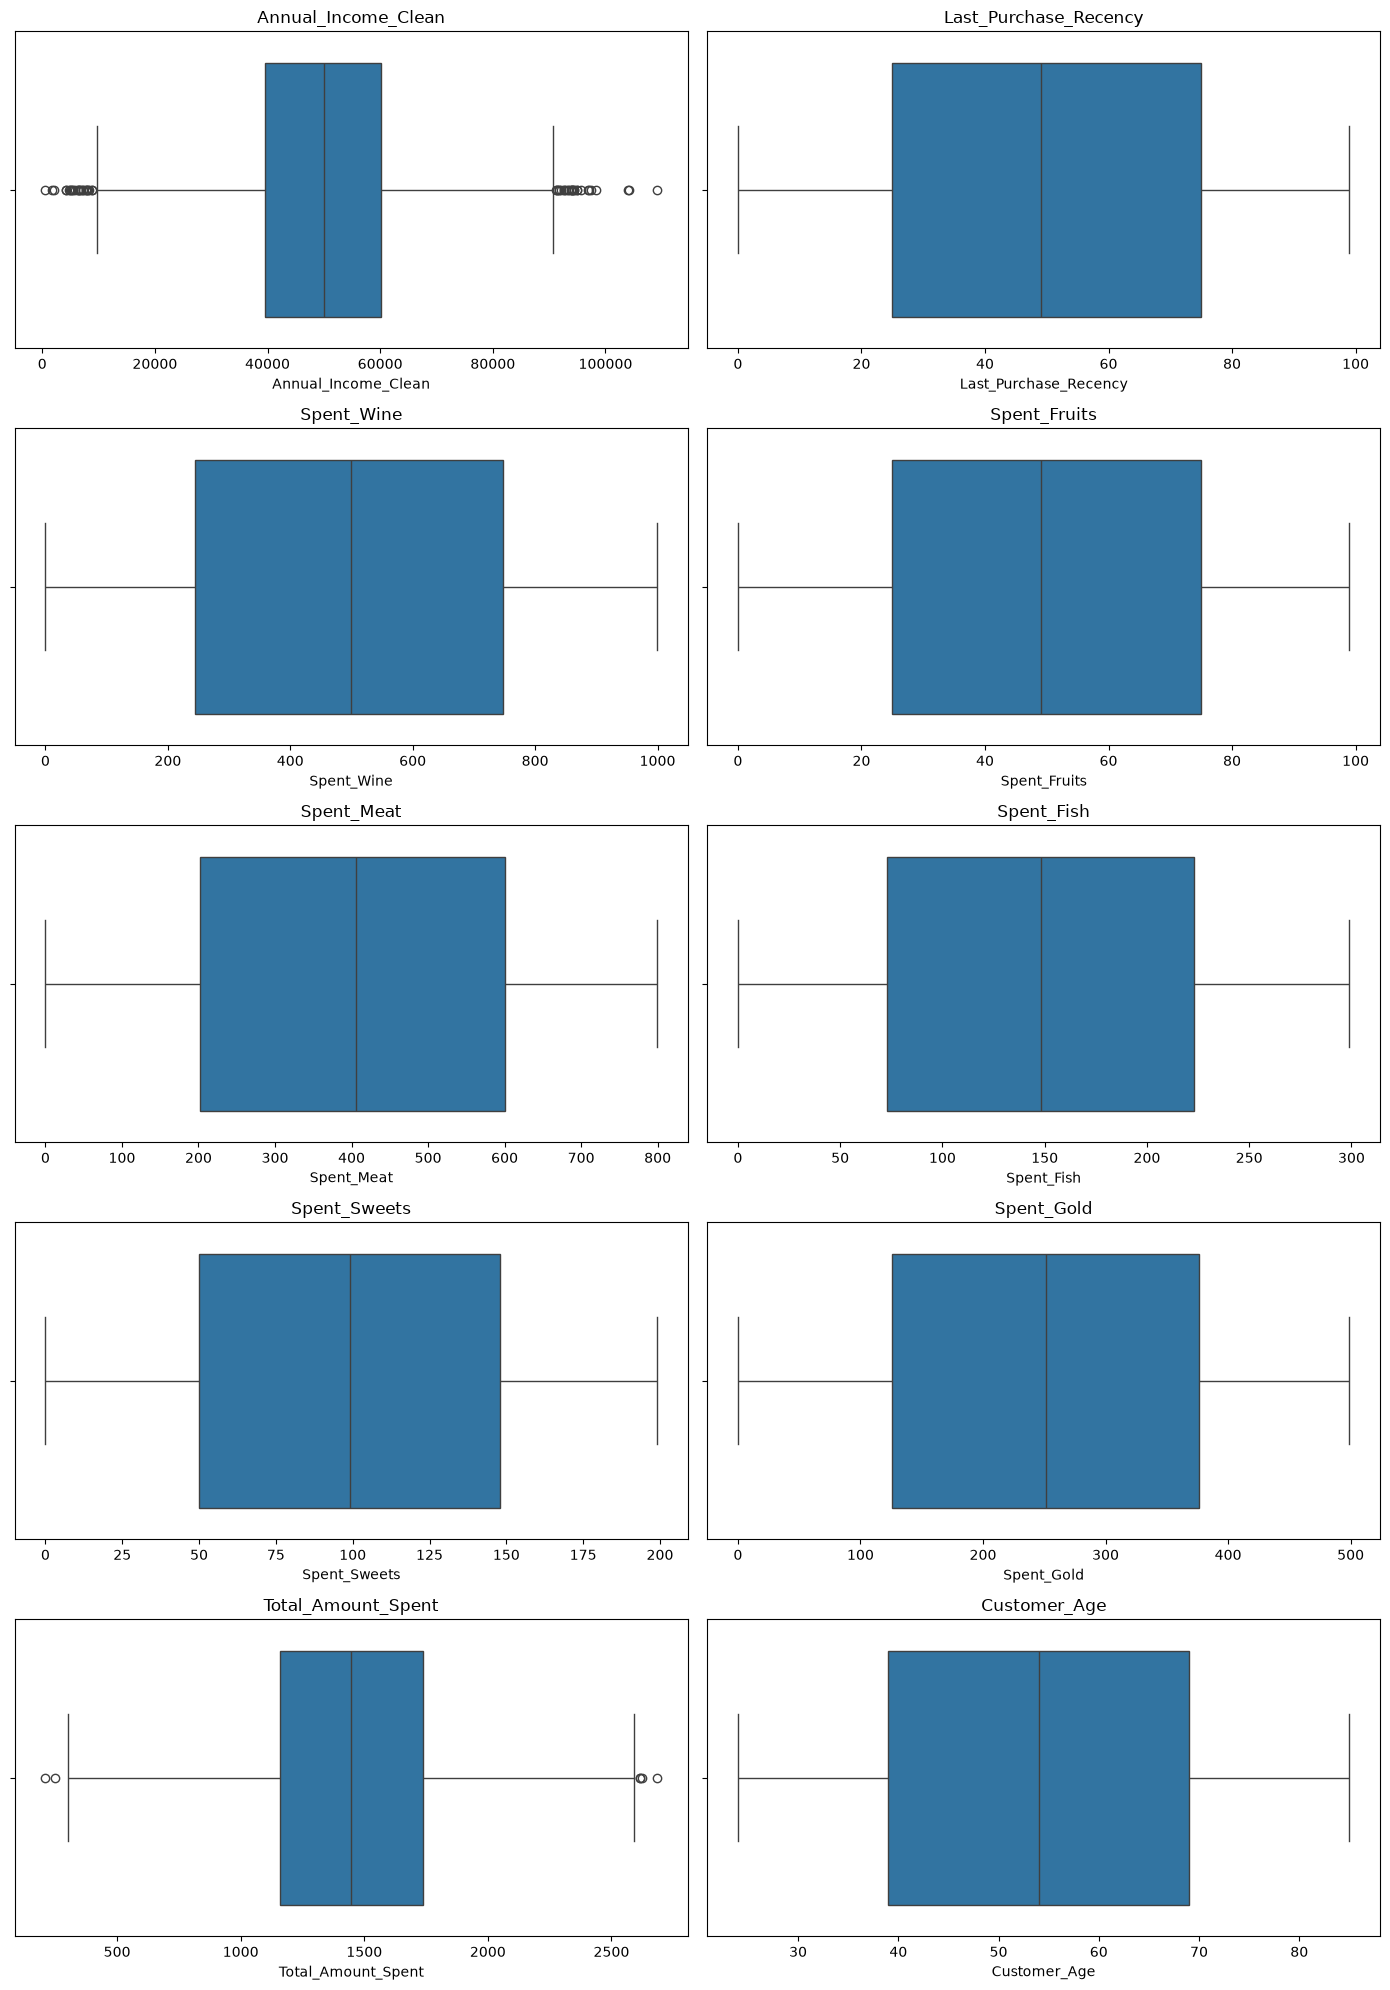

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_check = [
    "Annual_Income_Clean",
    "Last_Purchase_Recency",
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold",
    "Total_Amount_Spent",
    "Customer_Age"
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

axes = axes.flatten()

for i, column in enumerate(columns_to_check):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

In [36]:
outlier_summary = []

for column in columns_to_check:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Annual_Income_Clean,39633.825,60061.835,20428.01,8991.810,90703.850,52
1,Last_Purchase_Recency,25.000,75.000,50.00,-50.000,150.000,0
2,Spent_Wine,245.000,747.000,502.00,-508.000,1500.000,0
3,Spent_Fruits,25.000,75.000,50.00,-50.000,150.000,0
4,Spent_Meat,202.000,600.000,398.00,-395.000,1197.000,0
5,Spent_Fish,73.000,223.000,150.00,-152.000,448.000,0
6,Spent_Sweets,50.000,148.000,98.00,-97.000,295.000,0
7,Spent_Gold,126.000,376.000,250.00,-249.000,751.000,0
8,Total_Amount_Spent,1158.750,1736.000,577.25,292.875,2601.875,6
9,Customer_Age,39.000,69.000,30.00,-6.000,114.000,0


In [37]:
Q1 = df["Annual_Income_Clean"].quantile(0.25)
Q3 = df["Annual_Income_Clean"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[
    (df["Annual_Income_Clean"] < lower_bound) |
    (df["Annual_Income_Clean"] > upper_bound)
]

income_outliers[
    [
        "Customer_ID",
        "Annual_Income_Clean",
        "Total_Amount_Spent",
        "Membership_Tier",
        "Country",
        "City"
    ]
].sort_values("Annual_Income_Clean").head(10)

,Customer_ID,Annual_Income_Clean,Total_Amount_Spent,Membership_Tier,Country,City
4160,4161,566.58,1424,Gold,Germany,Berlin
3223,3224,1805.70,1339,Silver,UK,São Paulo
2035,2036,2011.03,1263,Basic,India,New York
8900,8901,4164.37,2044,Basic,USA,Berlin
7579,7580,4170.23,1165,Silver,India,New York
7240,7241,4691.36,1501,Gold,UK,New York
8486,8487,4859.88,2063,Gold,USA,São Paulo
6490,6491,5140.98,1183,Silver,India,London
207,208,5359.51,2025,Gold,USA,Mumbai
2734,2735,5521.84,1695,Basic,Germany,São Paulo


In [38]:
Q1 = df["Total_Amount_Spent"].quantile(0.25)
Q3 = df["Total_Amount_Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

spending_outliers = df[
    (df["Total_Amount_Spent"] < lower_bound) |
    (df["Total_Amount_Spent"] > upper_bound)
]

spending_outliers[
    [
        "Customer_ID",
        "Total_Amount_Spent",
        "Annual_Income_Clean",
        "Spent_Wine",
        "Spent_Fruits",
        "Spent_Meat",
        "Spent_Fish",
        "Spent_Sweets",
        "Spent_Gold"
    ]
].sort_values("Total_Amount_Spent")

,Customer_ID,Total_Amount_Spent,Annual_Income_Clean,Spent_Wine,Spent_Fruits,Spent_Meat,Spent_Fish,Spent_Sweets,Spent_Gold
6253,6254,210,41138.29,37,20,90,9,5,49
8448,8449,247,47796.68,104,12,7,56,55,13
1088,1089,2614,48048.94,937,72,719,284,142,460
8390,8391,2616,55516.82,925,39,764,267,168,453
3476,3477,2623,63825.37,979,69,754,282,94,445
4368,4369,2684,24391.38,994,78,777,224,177,434


In [39]:
spending_outliers = spending_outliers.copy()

spending_outliers["Outlier_Type"] = "High Spending"

spending_outliers.loc[
    spending_outliers["Total_Amount_Spent"] < lower_bound,
    "Outlier_Type"
] = "Low Spending"

spending_outliers[
    [
        "Customer_ID",
        "Total_Amount_Spent",
        "Outlier_Type",
        "Last_Purchase_Recency",
        "Web_Purchases",
        "Catalog_Purchases",
        "Store_Purchases"
    ]
].sort_values("Total_Amount_Spent")

,Customer_ID,Total_Amount_Spent,Outlier_Type,Last_Purchase_Recency,Web_Purchases,Catalog_Purchases,Store_Purchases
6253,6254,210,Low Spending,78,1,1,0
8448,8449,247,Low Spending,88,5,0,7
1088,1089,2614,High Spending,3,7,4,5
8390,8391,2616,High Spending,12,6,3,2
3476,3477,2623,High Spending,3,3,9,6
4368,4369,2684,High Spending,11,3,3,3


In [40]:
spending_outliers[
    [
        "Customer_ID",
        "Total_Amount_Spent",
        "Outlier_Type",
        "Last_Purchase_Recency"
    ]
].sort_values("Total_Amount_Spent")

,Customer_ID,Total_Amount_Spent,Outlier_Type,Last_Purchase_Recency
6253,6254,210,Low Spending,78
8448,8449,247,Low Spending,88
1088,1089,2614,High Spending,3
8390,8391,2616,High Spending,12
3476,3477,2623,High Spending,3
4368,4369,2684,High Spending,11


In [41]:
spending_outliers.groupby("Outlier_Type").agg(
    Customers=("Customer_ID", "count"),
    Average_Spending=("Total_Amount_Spent", "mean"),
    Average_Recency=("Last_Purchase_Recency", "mean")
).round(2)

,Customers,Average_Spending,Average_Recency
Outlier_Type,,,
High Spending,4,2634.25,7.25
Low Spending,2,228.50,83.00


In [42]:
df["Spending_Outlier_Type"] = "Normal"

df.loc[
    df["Total_Amount_Spent"] < lower_bound,
    "Spending_Outlier_Type"
] = "Low Spending Outlier"

df.loc[
    df["Total_Amount_Spent"] > upper_bound,
    "Spending_Outlier_Type"
] = "High Spending Outlier"

In [43]:
df["Spending_Outlier_Type"].value_counts()

Spending_Outlier_Type
Normal                   9994
High Spending Outlier       4
Low Spending Outlier        2
Name: count, dtype: int64

In [44]:
Q1_income = df["Annual_Income_Clean"].quantile(0.25)
Q3_income = df["Annual_Income_Clean"].quantile(0.75)

IQR_income = Q3_income - Q1_income

income_lower_bound = Q1_income - 1.5 * IQR_income
income_upper_bound = Q3_income + 1.5 * IQR_income

print("Income Lower Bound:", income_lower_bound)
print("Income Upper Bound:", income_upper_bound)

Income Lower Bound: 8991.809999999994
Income Upper Bound: 90703.85


In [45]:
income_outliers = income_outliers.copy()

income_outliers["Income_Outlier_Type"] = "High Income"

income_outliers.loc[
    income_outliers["Annual_Income_Clean"] < income_lower_bound,
    "Income_Outlier_Type"
] = "Low Income"

income_outliers["Income_Outlier_Type"].value_counts()

Income_Outlier_Type
High Income    27
Low Income     25
Name: count, dtype: int64

In [46]:
income_outliers[
    [
        "Customer_ID",
        "Annual_Income_Clean",
        "Income_Outlier_Type",
        "Total_Amount_Spent",
        "Last_Purchase_Recency",
        "Web_Purchases",
        "Catalog_Purchases",
        "Store_Purchases",
        "Membership_Tier"
    ]
].head(10)

,Customer_ID,Annual_Income_Clean,Income_Outlier_Type,Total_Amount_Spent,Last_Purchase_Recency,Web_Purchases,Catalog_Purchases,Store_Purchases,Membership_Tier
165,166,94957.97,High Income,1424,80,1,7,8,Silver
207,208,5359.51,Low Income,2025,63,3,1,8,Gold
220,221,92705.14,High Income,1710,45,4,5,4,Silver
424,425,8877.66,Low Income,1508,84,6,7,2,Basic
452,453,94072.82,High Income,1618,42,0,4,2,Basic
653,654,109134.97,High Income,1517,30,8,0,1,Basic
1040,1041,92594.34,High Income,1441,60,1,2,3,Silver
1181,1182,91748.53,High Income,1556,2,7,9,6,Basic
1187,1188,6326.75,Low Income,1025,43,8,8,4,Gold
1292,1293,93954.80,High Income,1416,82,5,4,4,Silver


In [47]:
income_outliers.groupby("Income_Outlier_Type").agg(
    Customers=("Customer_ID", "count"),
    Avg_Income=("Annual_Income_Clean", "mean"),
    Avg_Spending=("Total_Amount_Spent", "mean"),
    Avg_Recency=("Last_Purchase_Recency", "mean"),
    Avg_Web_Purchases=("Web_Purchases", "mean"),
    Avg_Catalog_Purchases=("Catalog_Purchases", "mean"),
    Avg_Store_Purchases=("Store_Purchases", "mean")
).round(2)

,Customers,Avg_Income,Avg_Spending,Avg_Recency,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases
Income_Outlier_Type,,,,,,,
High Income,27,95271.24,1462.96,51.96,4.33,4.22,4.26
Low Income,25,5973.30,1445.52,56.64,5.28,3.88,4.84


In [48]:
income_outliers.groupby("Income_Outlier_Type")[
    [
        "Annual_Income_Clean",
        "Total_Amount_Spent",
        "Last_Purchase_Recency"
    ]
].mean().round(2)

,Annual_Income_Clean,Total_Amount_Spent,Last_Purchase_Recency
Income_Outlier_Type,,,
High Income,95271.24,1462.96,51.96
Low Income,5973.30,1445.52,56.64


In [49]:
df["Income_Outlier_Type"] = "Normal"

df.loc[
    df["Annual_Income_Clean"] < income_lower_bound,
    "Income_Outlier_Type"
] = "Low Income Outlier"

df.loc[
    df["Annual_Income_Clean"] > income_upper_bound,
    "Income_Outlier_Type"
] = "High Income Outlier"

In [50]:
df["Income_Outlier_Type"].value_counts()

Income_Outlier_Type
Normal                 9948
High Income Outlier      27
Low Income Outlier       25
Name: count, dtype: int64

In [51]:
correlation_columns = [
    "Annual_Income_Clean",
    "Customer_Age",
    "Last_Purchase_Recency",
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold",
    "Total_Amount_Spent",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases",
    "Deals_Purchased",
    "Monthly_Web_Visits"
]

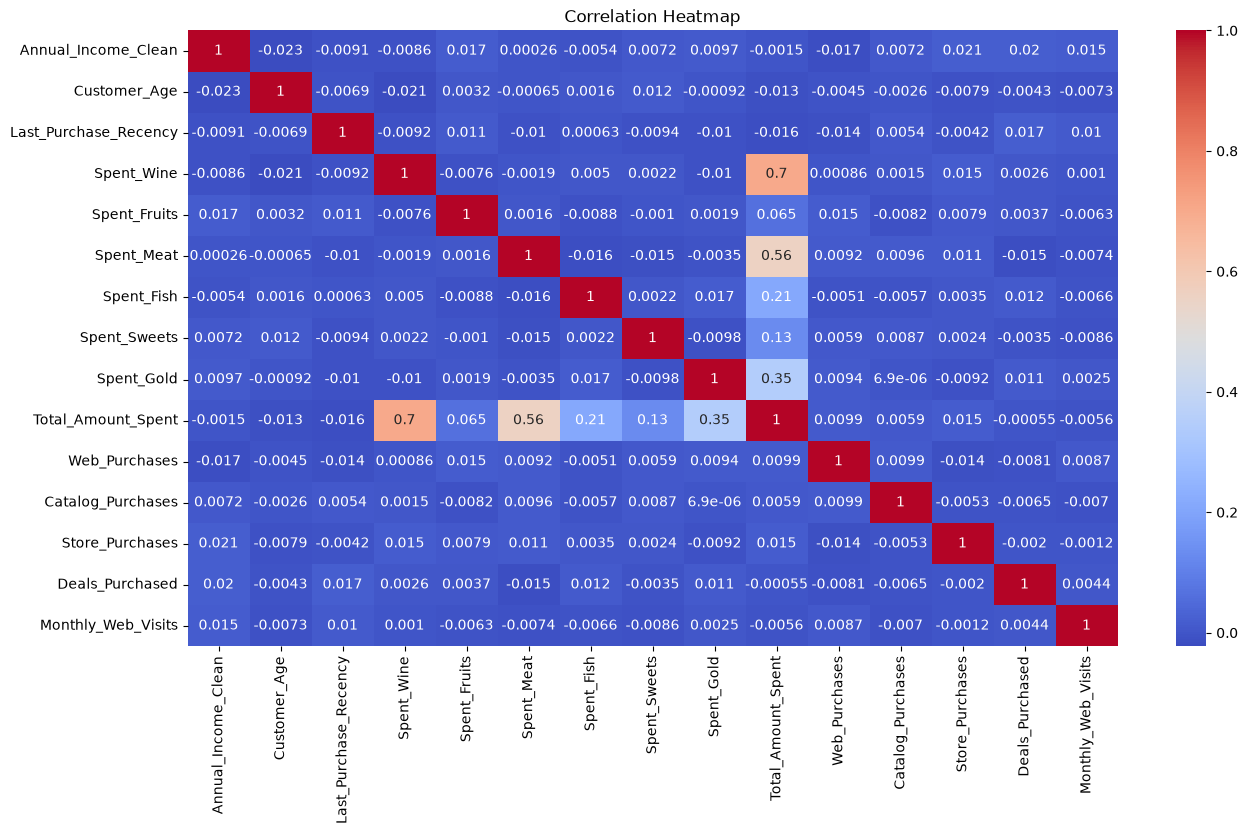

In [52]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    df[correlation_columns].corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [53]:
distribution_columns = [
    "Annual_Income_Clean",
    "Customer_Age",
    "Last_Purchase_Recency",
    "Total_Amount_Spent",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases",
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold"
]

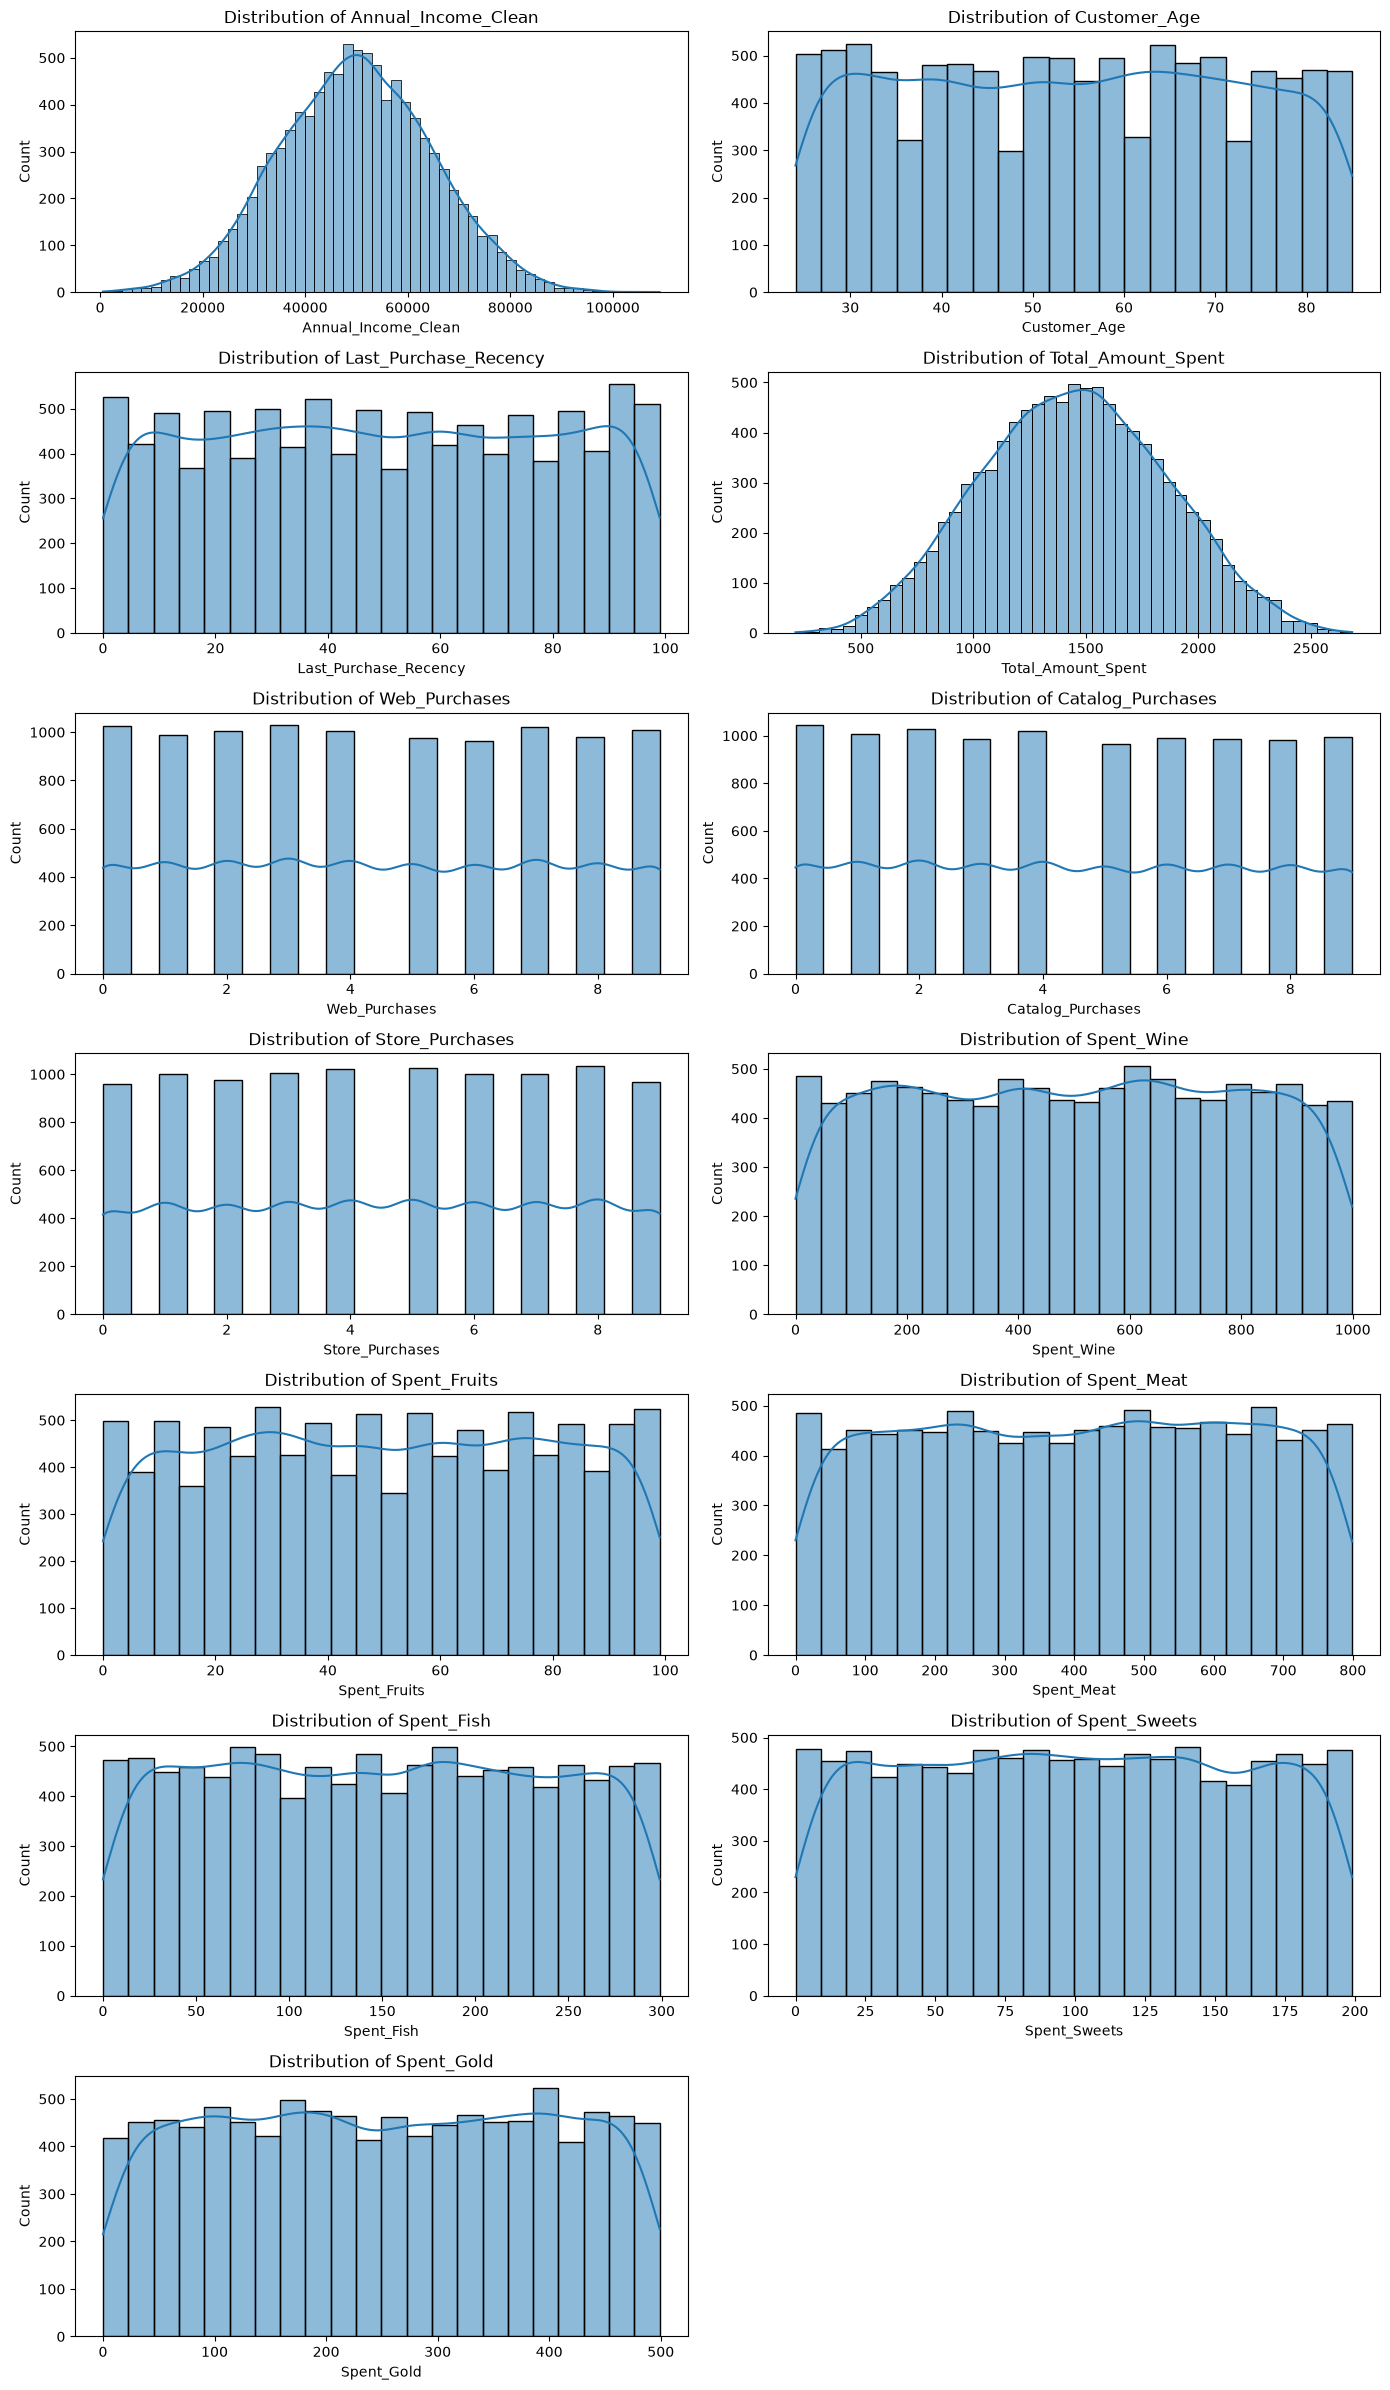

In [54]:
fig, axes = plt.subplots(7, 2, figsize=(14, 24))

axes = axes.flatten()

for i, column in enumerate(distribution_columns):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis – Key Insights

1. The dataset contains 10,000 unique customers and originally contains
   42 variables. No fully duplicated records, repeated customer IDs or
   missing values were found.

2. Five customers have negative annual income values. These values are
   economically invalid, so the original values were preserved using an
   Income_Review_Flag and excluded from numerical analysis through the
   Annual_Income_Clean feature.

3. The 675 customers with Family_Size equal to zero are not data errors.
   Family_Size exactly matches the available household definition based on
   children, teenagers and partner status for all 10,000 customers.

4. City and country are inconsistent for 7,981 customers (79.81%).
   Because the dataset does not provide verified addresses, these values
   should not be automatically corrected. Geography-based results must be
   treated cautiously.

5. Total_Amount_Spent exactly equals the sum of spending across wine,
   fruits, meat, fish, sweets and gold for every customer. Therefore,
   Total_Amount_Spent should not be used together with all six component
   variables during clustering because it would double-count spending.

6. Customer_Age and Birth_Year are perfectly related to the reference year
   2025. Only one of these variables should be used during modelling.

7. Contact_Cost and Revenue_Contribution contain only one value across all
   customers. They provide no customer-separation information and should be
   excluded from clustering.

8. Eight customers recorded positive spending despite having zero web,
   catalogue and store purchases. These records represent unusual behavioural
   patterns and have been retained for anomaly investigation.

9. IQR analysis identified 52 income outliers: 25 low-income and 27
   high-income customers. Their average spending is very similar
   (approximately 1,446 versus 1,463), suggesting that income does not
   strongly explain spending in this dataset.

10. Six total-spending outliers were identified. Four high-spending customers
    averaged 2,634 in spending with an average recency of 7.25 days, while
    two low-spending customers averaged 228.5 with an average recency of
    83 days. This indicates a meaningful high-engagement versus low-engagement
    behavioural difference.

11. The correlation analysis shows almost no relationship between income,
    age, recency, purchase channels and individual spending behaviour.
    Total spending is correlated with wine (0.70), meat (0.56), gold (0.35),
    fish (0.21), sweets (0.13) and fruits (0.065) because it is mathematically
    calculated from these variables.

12. Most product-spending and purchase-count variables appear approximately
    uniformly distributed, while annual income and total spending are closer
    to bell-shaped distributions. Combined with the very weak correlations,
    this suggests that the dataset may be synthetically generated and may
    not contain strongly separated natural customer groups.

13. Clustering can still be performed to create operational customer profiles,
    but cluster quality must be validated using silhouette score, cluster
    sizes, stability and business interpretability. The existence of useful
    segments should not be assumed in advance.

# Problem 1: Purchasing Behaviour Segmentation Using K-Means

The objective is to group customers according to purchase recency,
total spending and usage of web, catalogue and store channels. These
segments will help the retailer design differentiated marketing strategies.

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_features = [
    "Last_Purchase_Recency",
    "Total_Amount_Spent",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases"
]

X_kmeans = df[kmeans_features].copy()

X_kmeans.describe()

,Last_Purchase_Recency,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.592500,1447.778100,4.482300,4.456100,4.520300
std,29.101686,408.159165,2.879638,2.884043,2.853489
min,0.000000,210.000000,0.000000,0.000000,0.000000
25%,25.000000,1158.750000,2.000000,2.000000,2.000000
50%,49.000000,1447.000000,4.000000,4.000000,5.000000
75%,75.000000,1736.000000,7.000000,7.000000,7.000000
max,99.000000,2684.000000,9.000000,9.000000,9.000000


In [56]:
scaler_kmeans = StandardScaler()

X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

X_kmeans_scaled = pd.DataFrame(
    X_kmeans_scaled,
    columns=kmeans_features,
    index=df.index
)

X_kmeans_scaled.head()

,Last_Purchase_Recency,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases
0,0.632555,-0.447833,-0.514778,-0.851660,-0.883279
1,1.697839,0.488123,-1.209344,0.188599,-1.584210
2,0.460735,0.877696,0.874355,0.535352,0.168118
3,0.529463,-0.589942,1.221638,-0.504907,-0.883279
4,-0.020361,-1.258832,0.874355,-0.504907,0.518584


In [59]:
k_results = []

for k in range(2, 12):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_kmeans_scaled)

    k_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette_Score": silhouette_score(
            X_kmeans_scaled,
            labels
        )
    })

k_results = pd.DataFrame(k_results)

k_results

,K,Inertia,Silhouette_Score
0,2,42406.552816,0.151319
1,3,37744.856400,0.138876
2,4,34106.786805,0.145542
3,5,31287.828521,0.150174
4,6,28990.871054,0.152100
5,7,27208.504649,0.153632
6,8,25508.392184,0.161709
7,9,23959.031926,0.166201
8,10,22688.654941,0.168360
9,11,21847.073924,0.164766


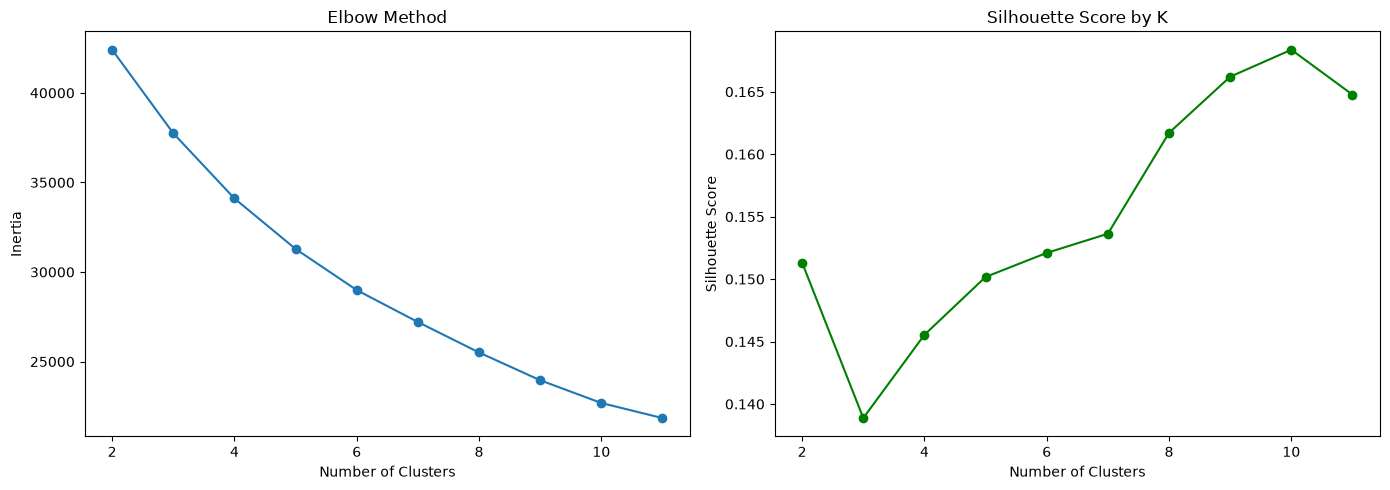

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    k_results["K"],
    k_results["Inertia"],
    marker="o"
)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(
    k_results["K"],
    k_results["Silhouette_Score"],
    marker="o",
    color="green"
)
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [61]:
final_k = 6

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = final_kmeans.fit_predict(
    X_kmeans_scaled
)

df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    1485
1    1861
2    1597
3    1776
4    1730
5    1551
Name: count, dtype: int64

In [ ]:
kmeans_profile = (
    df.groupby("KMeans_Cluster")
    .agg(
        Customers=("Customer_ID", "count"),
        Avg_Recency=("Last_Purchase_Recency", "mean"),
        Avg_Total_Spending=("Total_Amount_Spent", "mean"),
        Avg_Web_Purchases=("Web_Purchases", "mean"),
        Avg_Catalog_Purchases=("Catalog_Purchases", "mean"),
        Avg_Store_Purchases=("Store_Purchases", "mean")
    )
    .round(2)
)

kmeans_profile["Customer_Percentage"] = (
    kmeans_profile["Customers"] / len(df) * 100
).round(2)

kmeans_profile

,Customers,Avg_Recency,Avg_Total_Spending,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Customer_Percentage
KMeans_Cluster,,,,,,,
0,1485,61.88,1873.27,5.13,7.02,3.37,14.85
1,1861,19.93,1561.41,4.58,4.28,7.13,18.61
2,1597,35.18,1204.66,2.26,5.92,2.20,15.97
3,1776,70.08,1511.22,2.08,2.03,5.34,17.76
4,1730,44.23,1402.20,6.98,2.06,2.29,17.30
5,1551,70.78,1132.57,6.00,6.15,6.44,15.51


In [63]:
final_k = 10

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = final_kmeans.fit_predict(
    X_kmeans_scaled
)

df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0     996
1    1088
2    1049
3     887
4     984
5    1011
6    1004
7    1009
8     936
9    1036
Name: count, dtype: int64

In [64]:
kmeans_profile = (
    df.groupby("KMeans_Cluster")
    .agg(
        Customers=("Customer_ID", "count"),
        Avg_Recency=("Last_Purchase_Recency", "mean"),
        Avg_Total_Spending=("Total_Amount_Spent", "mean"),
        Avg_Web_Purchases=("Web_Purchases", "mean"),
        Avg_Catalog_Purchases=("Catalog_Purchases", "mean"),
        Avg_Store_Purchases=("Store_Purchases", "mean")
    )
    .round(2)
)

kmeans_profile["Customer_Percentage"] = (
    kmeans_profile["Customers"] / len(df) * 100
).round(2)

kmeans_profile

,Customers,Avg_Recency,Avg_Total_Spending,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Customer_Percentage
KMeans_Cluster,,,,,,,
0,996,74.72,1147.13,2.72,6.74,6.48,9.96
1,1088,24.95,1715.22,6.62,2.54,2.51,10.88
2,1049,73.04,1586.62,1.82,2.73,2.35,10.49
3,887,60.58,978.53,6.44,2.07,2.81,8.87
4,984,25.00,1286.31,7.18,6.13,6.85,9.84
5,1011,28.11,1248.15,2.71,6.68,1.74,10.11
6,1004,73.88,1602.86,6.83,7.11,2.61,10.04
7,1009,73.51,1633.66,5.95,2.29,7.28,10.09
8,936,36.07,1914.04,2.79,6.63,6.25,9.36


In [65]:
segment_names = {
    0: "Dormant Small-Basket Offline Buyers",
    1: "Recent High-Value Web Shoppers",
    2: "Lapsed High-Ticket Occasional Buyers",
    3: "At-Risk Budget Web Shoppers",
    4: "Active Omnichannel Regulars",
    5: "Active Catalogue-Focused Buyers",
    6: "Lapsed Web-Catalogue Loyalists",
    7: "Lapsed Store-Led High-Value Buyers",
    8: "Premium Offline Champions",
    9: "Active Store-Focused Buyers"
}

df["KMeans_Segment"] = df["KMeans_Cluster"].map(segment_names)

In [66]:
marketing_actions = {
    0: "Send catalogue and store reactivation coupons",
    1: "Provide web-exclusive recommendations and loyalty benefits",
    2: "Launch personalized premium win-back campaigns",
    3: "Offer affordable online bundles and limited-time discounts",
    4: "Provide omnichannel loyalty rewards and cross-channel promotions",
    5: "Send personalized catalogue recommendations and bundles",
    6: "Run a high-priority web and catalogue win-back campaign",
    7: "Provide store vouchers, invitations and loyalty reminders",
    8: "Provide VIP retention benefits and premium offers",
    9: "Offer in-store loyalty points and personalized coupons"
}

df["Marketing_Action"] = df["KMeans_Cluster"].map(marketing_actions)

In [67]:
final_kmeans_summary = kmeans_profile.copy()

final_kmeans_summary["Segment_Name"] = (
    final_kmeans_summary.index.map(segment_names)
)

final_kmeans_summary["Marketing_Action"] = (
    final_kmeans_summary.index.map(marketing_actions)
)

final_kmeans_summary = final_kmeans_summary[
    [
        "Segment_Name",
        "Customers",
        "Customer_Percentage",
        "Avg_Recency",
        "Avg_Total_Spending",
        "Avg_Web_Purchases",
        "Avg_Catalog_Purchases",
        "Avg_Store_Purchases",
        "Marketing_Action"
    ]
]

final_kmeans_summary

,Segment_Name,Customers,Customer_Percentage,Avg_Recency,Avg_Total_Spending,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Marketing_Action
KMeans_Cluster,,,,,,,,,
0,Dormant Small-Basket Offline Buyers,996,9.96,74.72,1147.13,2.72,6.74,6.48,Send catalogue and store reactivation coupons
1,Recent High-Value Web Shoppers,1088,10.88,24.95,1715.22,6.62,2.54,2.51,Provide web-exclusive recommendations and loya...
2,Lapsed High-Ticket Occasional Buyers,1049,10.49,73.04,1586.62,1.82,2.73,2.35,Launch personalized premium win-back campaigns
3,At-Risk Budget Web Shoppers,887,8.87,60.58,978.53,6.44,2.07,2.81,Offer affordable online bundles and limited-ti...
4,Active Omnichannel Regulars,984,9.84,25.00,1286.31,7.18,6.13,6.85,Provide omnichannel loyalty rewards and cross-...
5,Active Catalogue-Focused Buyers,1011,10.11,28.11,1248.15,2.71,6.68,1.74,Send personalized catalogue recommendations an...
6,Lapsed Web-Catalogue Loyalists,1004,10.04,73.88,1602.86,6.83,7.11,2.61,Run a high-priority web and catalogue win-back...
7,Lapsed Store-Led High-Value Buyers,1009,10.09,73.51,1633.66,5.95,2.29,7.28,"Provide store vouchers, invitations and loyalt..."
8,Premium Offline Champions,936,9.36,36.07,1914.04,2.79,6.63,6.25,Provide VIP retention benefits and premium offers


### K-Means Business Conclusion

K=10 was selected because it achieved the highest silhouette score of
0.1684 among the evaluated values. Each cluster contains approximately
9%–11% of customers, indicating that the solution does not create
extremely small segments.

The resulting segments distinguish recent and lapsed customers,
high- and low-spending customers, and web-, catalogue-, store- and
omnichannel purchase behaviours. Each segment was assigned a specific
marketing action covering retention, reactivation, channel targeting,
upselling or VIP treatment.

Because the silhouette score is relatively low, the clusters should be
treated as operational marketing segments rather than strongly separated
natural customer groups.

# Problem 2: Product-Preference Hierarchy Using Agglomerative Clustering

## Business Problem

The retailer needs to understand customers' broad product preferences and identify smaller preference groups within them.

## What We Analyse

We analyse each customer's spending proportion across:

- Wine
- Fruits
- Meat
- Fish
- Sweets
- Gold

Spending proportions are used instead of actual amounts because the objective is to identify which products customers prefer, rather than whether they are high or low spenders.

## Approach

Agglomerative Hierarchical Clustering starts with every customer as a separate cluster and repeatedly merges the most similar customers or groups.

This creates:

- **Parent groups:** Broad product-preference groups.
- **Child groups:** Smaller and more specific preferences within each parent group.

## Business Action

Build a customer-preference hierarchy to support broad product campaigns, personalised category offers, product recommendations and cross-selling opportunities.

## Objective

Group customers according to the proportion of their spending allocated to wine, fruits, meat, fish, sweets and gold, and create broad parent segments with detailed child segments.

In [68]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

product_columns = [
    "Spent_Wine",
    "Spent_Fruits",
    "Spent_Meat",
    "Spent_Fish",
    "Spent_Sweets",
    "Spent_Gold"
]

product_totals = df[product_columns].sum(axis=1)

print("Customers with zero spending:", (product_totals == 0).sum())

Customers with zero spending: 0


In [69]:
X_preference = df[product_columns].div(
    product_totals,
    axis=0
)

X_preference.columns = [
    "Wine_Share",
    "Fruits_Share",
    "Meat_Share",
    "Fish_Share",
    "Sweets_Share",
    "Gold_Share"
]

X_preference.head()

,Wine_Share,Fruits_Share,Meat_Share,Fish_Share,Sweets_Share,Gold_Share
0,0.347826,0.026877,0.373913,0.169960,0.045850,0.035573
1,0.501518,0.014572,0.111111,0.054038,0.102004,0.216758
2,0.495570,0.001107,0.174419,0.057586,0.107973,0.163344
3,0.105220,0.041425,0.492129,0.086164,0.080365,0.194698
4,0.149893,0.052463,0.079229,0.228051,0.185225,0.305139


In [70]:
preference_validation = pd.DataFrame({
    "Minimum_Share": X_preference.min(),
    "Maximum_Share": X_preference.max(),
    "Average_Share": X_preference.mean()
}).round(4)

print("Missing values:", X_preference.isnull().sum().sum())
print("Infinite values:", np.isinf(X_preference).sum().sum())
print("\nRow-total validation:")
print(X_preference.sum(axis=1).describe())

preference_validation

Missing values: 0
Infinite values: 0

Row-total validation:
count    1.000000e+04
mean     1.000000e+00
std      6.006802e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


,Minimum_Share,Maximum_Share,Average_Share
Wine_Share,0.0,0.8651,0.3292
Fruits_Share,0.0,0.2154,0.0374
Meat_Share,0.0,0.8247,0.2731
Fish_Share,0.0,0.5707,0.1085
Sweets_Share,0.0,0.5221,0.0737
Gold_Share,0.0,0.6802,0.1782


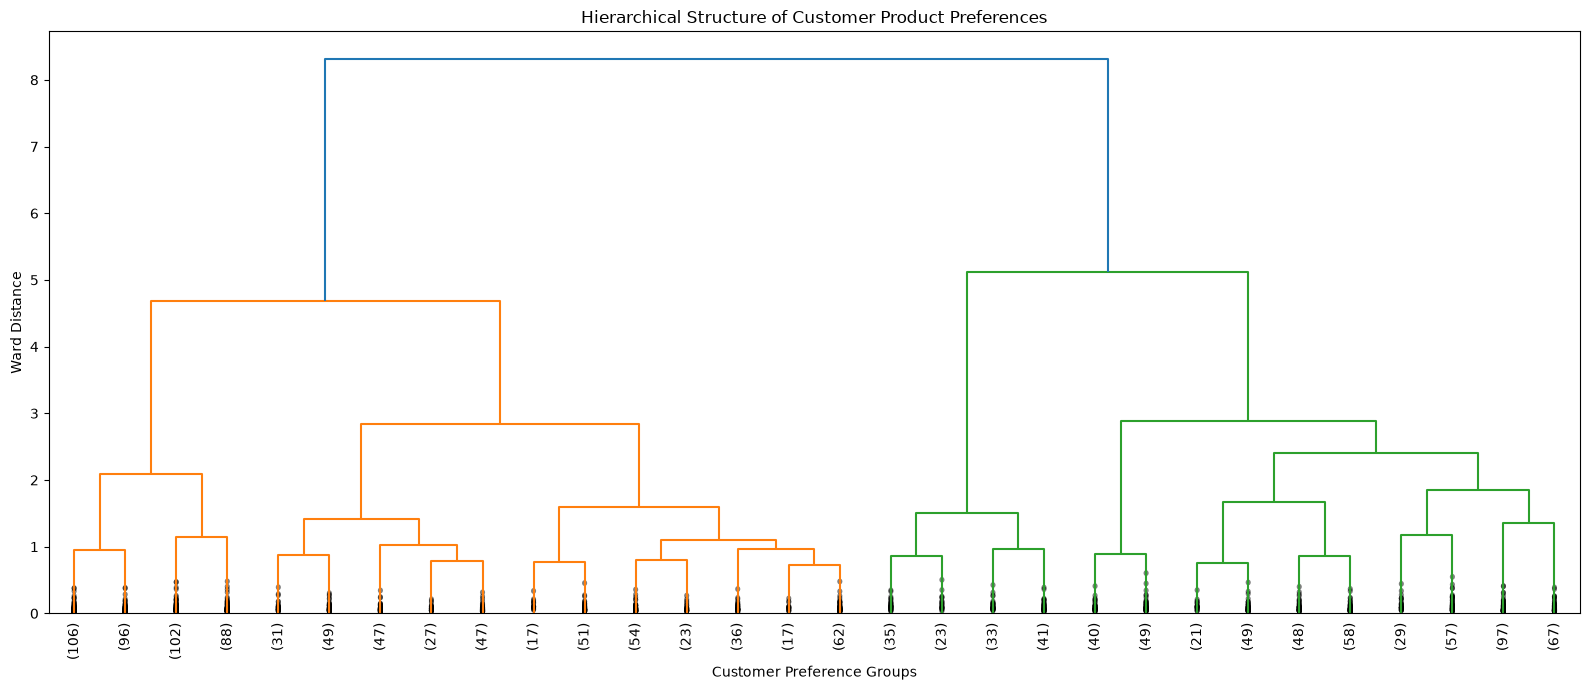

In [71]:
preference_sample = X_preference.sample(
    n=1500,
    random_state=42
)

linkage_matrix = linkage(
    preference_sample,
    method="ward"
)

plt.figure(figsize=(16, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    show_contracted=True,
    leaf_rotation=90
)

plt.title("Hierarchical Structure of Customer Product Preferences")
plt.xlabel("Customer Preference Groups")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [72]:
hierarchical_results = []

for k in range(2, 13):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(preference_sample)

    hierarchical_results.append({
        "K": k,
        "Silhouette_Score": silhouette_score(
            preference_sample,
            labels
        )
    })

hierarchical_results = pd.DataFrame(
    hierarchical_results
)

hierarchical_results

,K,Silhouette_Score
0,2,0.301917
1,3,0.286844
2,4,0.228037
3,5,0.212451
4,6,0.198122
5,7,0.189636
6,8,0.172750
7,9,0.174937
8,10,0.169507
9,11,0.161291


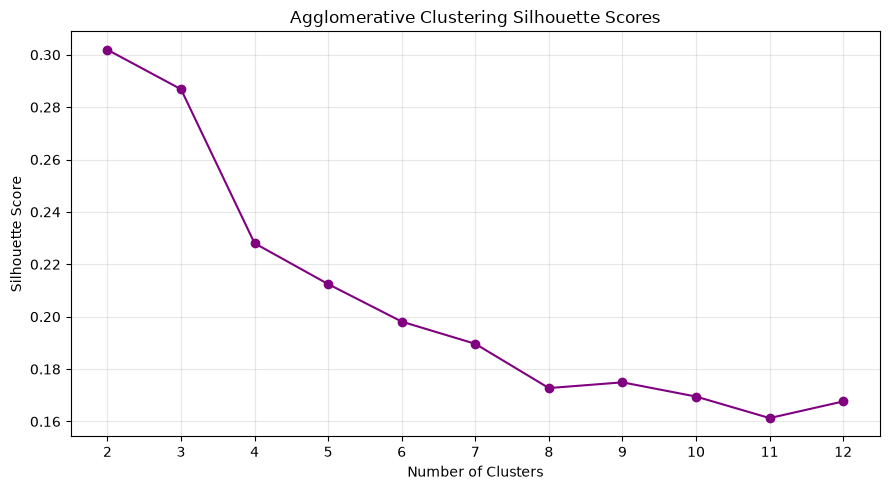

In [73]:
plt.figure(figsize=(9, 5))

plt.plot(
    hierarchical_results["K"],
    hierarchical_results["Silhouette_Score"],
    marker="o",
    color="purple"
)

plt.title("Agglomerative Clustering Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(hierarchical_results["K"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Selection of Hierarchy Levels

The dendrogram shows a clear top-level division into two major branches.
K=2 also achieved the highest silhouette score of 0.3019. Therefore,
two clusters were selected as the broad parent preference groups.

For detailed segmentation, K=5 was selected with a silhouette score of
0.2125. It provides meaningful child-level detail while maintaining
better separation than larger cluster counts. From K=6 onward, the
silhouette score falls below 0.20.

Therefore, the final hierarchy uses:

- **2 parent preference groups**
- **5 child preference groups**

In [74]:
parent_k = 2
child_k = 5

print("Selected parent groups:", parent_k)
print("Selected child groups:", child_k)

Selected parent groups: 2
Selected child groups: 5


In [75]:
parent_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward",
    compute_full_tree=True
)

child_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward",
    compute_full_tree=True
)

df["Preference_Parent_Cluster"] = (
    parent_model.fit_predict(X_preference)
)

df["Preference_Child_Cluster"] = (
    child_model.fit_predict(X_preference)
)

print("Parent cluster sizes:")
print(
    df["Preference_Parent_Cluster"]
    .value_counts()
    .sort_index()
)

print("\nChild cluster sizes:")
print(
    df["Preference_Child_Cluster"]
    .value_counts()
    .sort_index()
)

Parent cluster sizes:
Preference_Parent_Cluster
0    4369
1    5631
Name: count, dtype: int64

Child cluster sizes:
Preference_Child_Cluster
0    1852
1    2810
2    1689
3    2821
4     828
Name: count, dtype: int64


In [77]:
hierarchy_table = pd.crosstab(
    df["Preference_Child_Cluster"],
    df["Preference_Parent_Cluster"]
)

display(hierarchy_table)

parents_per_child = hierarchy_table.gt(0).sum(axis=1)

print(
    "\nEvery child belongs to exactly one parent:",
    parents_per_child.eq(1).all()
)

Preference_Parent_Cluster,0,1
Preference_Child_Cluster,,
0,1852,0
1,0,2810
2,1689,0
3,0,2821
4,828,0



Every child belongs to exactly one parent: True


In [78]:
parent_profile = (
    X_preference
    .assign(
        Parent_Cluster=df[
            "Preference_Parent_Cluster"
        ].values
    )
    .groupby("Parent_Cluster")
    .mean()
    .mul(100)
    .round(2)
)

parent_profile["Customers"] = (
    df["Preference_Parent_Cluster"]
    .value_counts()
    .sort_index()
)

parent_profile["Customer_Percentage"] = (
    parent_profile["Customers"] / len(df) * 100
).round(2)

parent_profile

,Wine_Share,Fruits_Share,Meat_Share,Fish_Share,Sweets_Share,Gold_Share,Customers,Customer_Percentage
Parent_Cluster,,,,,,,,
0,18.37,4.29,32.56,12.91,8.32,23.56,4369,43.69
1,44.21,3.31,23.23,9.26,6.63,13.36,5631,56.31


In [79]:
child_profile = (
    X_preference
    .assign(
        Child_Cluster=df[
            "Preference_Child_Cluster"
        ].values
    )
    .groupby("Child_Cluster")
    .mean()
    .mul(100)
    .round(2)
)

child_profile["Customers"] = (
    df["Preference_Child_Cluster"]
    .value_counts()
    .sort_index()
)

child_profile["Customer_Percentage"] = (
    child_profile["Customers"] / len(df) * 100
).round(2)

child_profile["Parent_Cluster"] = (
    df.groupby("Preference_Child_Cluster")[
        "Preference_Parent_Cluster"
    ]
    .first()
)

child_profile

,Wine_Share,Fruits_Share,Meat_Share,Fish_Share,Sweets_Share,Gold_Share,Customers,Customer_Percentage,Parent_Cluster
Child_Cluster,,,,,,,,,
0,21.88,4.91,18.03,15.81,9.38,29.99,1852,18.52,0
1,50.02,3.52,13.23,10.49,7.06,15.67,2810,28.10,1
2,16.09,3.64,39.53,10.23,7.05,23.47,1689,16.89,0
3,38.42,3.10,33.19,8.03,6.20,11.06,2821,28.21,1
4,15.15,4.25,50.83,11.88,8.52,9.36,828,8.28,0


In [80]:
parent_names = {
    0: "Meat and Gold Preference Group",
    1: "Wine-Led Preference Group"
}

child_names = {
    0: "Gold-Led Diverse Buyers",
    1: "Wine-Dominant Buyers",
    2: "Meat and Gold Buyers",
    3: "Wine and Meat Buyers",
    4: "Meat-Dominant Buyers"
}

df["Preference_Parent_Segment"] = (
    df["Preference_Parent_Cluster"].map(parent_names)
)

df["Preference_Child_Segment"] = (
    df["Preference_Child_Cluster"].map(child_names)
)

In [81]:
product_actions = {
    0: "Lead with gold offers and cross-sell fish, sweets and wine",
    1: "Promote wine-focused offers and cross-sell gold products",
    2: "Create combined meat and gold category promotions",
    3: "Design wine and meat combination campaigns",
    4: "Lead with meat offers and introduce related product categories"
}

df["Product_Marketing_Action"] = (
    df["Preference_Child_Cluster"].map(product_actions)
)

In [82]:
final_hierarchy_summary = child_profile.copy()

final_hierarchy_summary["Parent_Segment"] = (
    final_hierarchy_summary["Parent_Cluster"]
    .map(parent_names)
)

final_hierarchy_summary["Child_Segment"] = (
    final_hierarchy_summary.index.map(child_names)
)

final_hierarchy_summary["Business_Action"] = (
    final_hierarchy_summary.index.map(product_actions)
)

final_hierarchy_summary = final_hierarchy_summary[
    [
        "Parent_Cluster",
        "Parent_Segment",
        "Child_Segment",
        "Customers",
        "Customer_Percentage",
        "Wine_Share",
        "Fruits_Share",
        "Meat_Share",
        "Fish_Share",
        "Sweets_Share",
        "Gold_Share",
        "Business_Action"
    ]
].sort_values(
    ["Parent_Cluster", "Child_Segment"]
)

final_hierarchy_summary

,Parent_Cluster,Parent_Segment,Child_Segment,Customers,Customer_Percentage,Wine_Share,Fruits_Share,Meat_Share,Fish_Share,Sweets_Share,Gold_Share,Business_Action
Child_Cluster,,,,,,,,,,,,
0,0,Meat and Gold Preference Group,Gold-Led Diverse Buyers,1852,18.52,21.88,4.91,18.03,15.81,9.38,29.99,"Lead with gold offers and cross-sell fish, swe..."
2,0,Meat and Gold Preference Group,Meat and Gold Buyers,1689,16.89,16.09,3.64,39.53,10.23,7.05,23.47,Create combined meat and gold category promotions
4,0,Meat and Gold Preference Group,Meat-Dominant Buyers,828,8.28,15.15,4.25,50.83,11.88,8.52,9.36,Lead with meat offers and introduce related pr...
3,1,Wine-Led Preference Group,Wine and Meat Buyers,2821,28.21,38.42,3.10,33.19,8.03,6.20,11.06,Design wine and meat combination campaigns
1,1,Wine-Led Preference Group,Wine-Dominant Buyers,2810,28.10,50.02,3.52,13.23,10.49,7.06,15.67,Promote wine-focused offers and cross-sell gol...


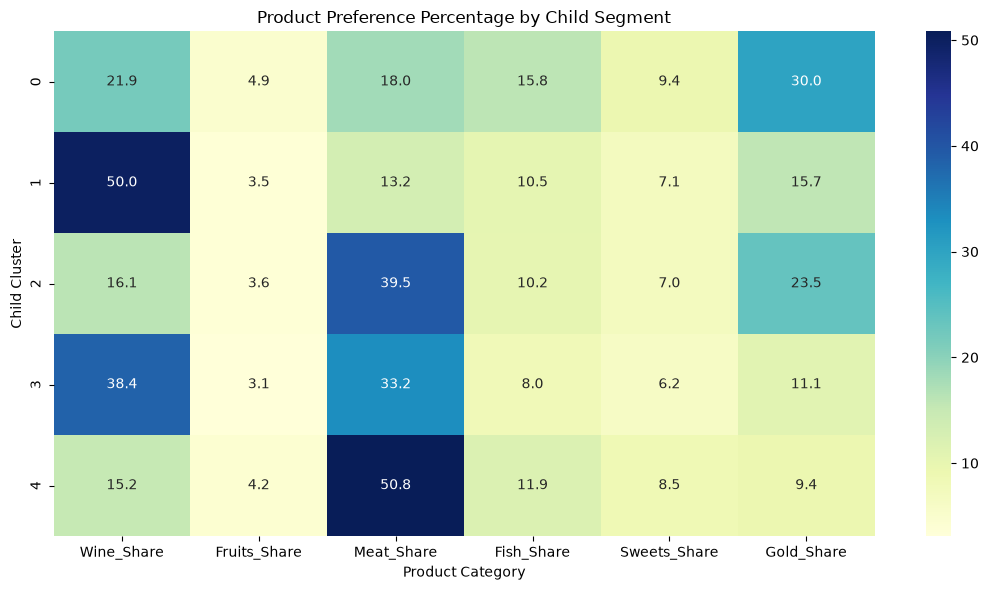

In [83]:
plt.figure(figsize=(11, 6))

sns.heatmap(
    child_profile[
        [
            "Wine_Share",
            "Fruits_Share",
            "Meat_Share",
            "Fish_Share",
            "Sweets_Share",
            "Gold_Share"
        ]
    ],
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Product Preference Percentage by Child Segment")
plt.xlabel("Product Category")
plt.ylabel("Child Cluster")
plt.tight_layout()
plt.show()

### Hierarchical Clustering Business Conclusion

Two parent groups and five child groups were selected using the dendrogram,
silhouette scores and business interpretability.

The first parent group contains 43.69% of customers and is characterised by
stronger meat and gold preferences. It contains Gold-Led Diverse Buyers,
Meat and Gold Buyers, and Meat-Dominant Buyers.

The second parent group contains 56.31% of customers and is primarily
wine-led. It contains Wine-Dominant Buyers and Wine and Meat Buyers.

This hierarchy allows the retailer to run broad campaigns for the two parent
groups and more personalised category campaigns for the five child segments.
The parent clustering achieved a silhouette score of 0.3019, while the
five-child solution achieved 0.2125.

# Problem 3: Unusual Customer Behaviour Detection Using DBSCAN

## Business Problem

Unusual customer records or purchasing patterns must be investigated before
they affect marketing and business decisions.

## What We Analyse

DBSCAN analyses:

- Last-purchase recency
- Total spending
- Web purchases
- Catalogue purchases
- Store purchases

DBSCAN identifies dense regions representing common customer behaviour.
Customers outside these dense regions are labelled as noise and treated as
potential anomalies.

Rule-based inconsistencies, such as customers reporting spending without
any channel purchases, are then combined with the DBSCAN result to create
a prioritised investigation list.

## Business Action

Produce a prioritised customer-review list with the behavioural feature
responsible for each unusual result.

In [84]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

dbscan_features = [
    "Last_Purchase_Recency",
    "Total_Amount_Spent",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases"
]

X_dbscan = df[dbscan_features].copy()

print("Shape:", X_dbscan.shape)
print("Missing values:", X_dbscan.isnull().sum().sum())

X_dbscan.describe()

Shape: (10000, 5)
Missing values: 0


,Last_Purchase_Recency,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.592500,1447.778100,4.482300,4.456100,4.520300
std,29.101686,408.159165,2.879638,2.884043,2.853489
min,0.000000,210.000000,0.000000,0.000000,0.000000
25%,25.000000,1158.750000,2.000000,2.000000,2.000000
50%,49.000000,1447.000000,4.000000,4.000000,5.000000
75%,75.000000,1736.000000,7.000000,7.000000,7.000000
max,99.000000,2684.000000,9.000000,9.000000,9.000000


In [85]:
dbscan_scaler = RobustScaler()

X_dbscan_scaled = dbscan_scaler.fit_transform(
    X_dbscan
)

X_dbscan_scaled = pd.DataFrame(
    X_dbscan_scaled,
    columns=dbscan_features,
    index=df.index
)

X_dbscan_scaled.head()

,Last_Purchase_Recency,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases
0,0.38,-0.315288,-0.2,-0.4,-0.6
1,1.00,0.346470,-0.6,0.2,-1.0
2,0.28,0.621914,0.6,0.4,0.0
3,0.32,-0.415764,0.8,-0.2,-0.6
4,0.00,-0.888696,0.6,-0.2,0.2


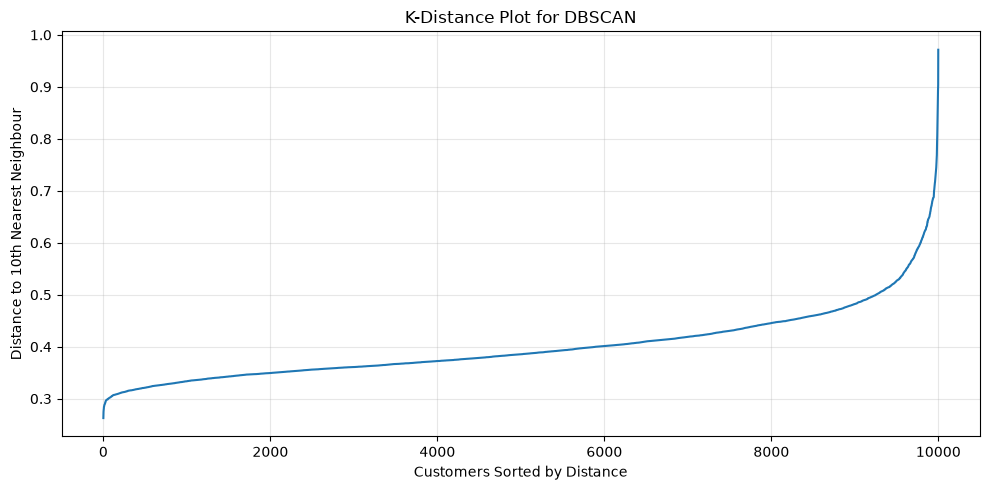

In [86]:
base_min_samples = 10

nearest_neighbors = NearestNeighbors(
    n_neighbors=base_min_samples
)

nearest_neighbors.fit(X_dbscan_scaled)

distances, indices = nearest_neighbors.kneighbors(
    X_dbscan_scaled
)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.title("K-Distance Plot for DBSCAN")
plt.xlabel("Customers Sorted by Distance")
plt.ylabel("Distance to 10th Nearest Neighbour")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
distance_percentiles = pd.Series({
    f"{percentile}th percentile": np.percentile(
        k_distances,
        percentile
    )
    for percentile in [
        80, 85, 90, 92, 94, 95, 96, 97, 98, 99
    ]
})

distance_percentiles.round(4)

80th percentile    0.4455
85th percentile    0.4596
90th percentile    0.4822
92th percentile    0.4960
94th percentile    0.5141
95th percentile    0.5268
96th percentile    0.5454
97th percentile    0.5698
98th percentile    0.6053
99th percentile    0.6552
dtype: float64

In [88]:
eps_candidates = np.unique(
    np.round(
        np.percentile(
            k_distances,
            [80, 85, 90, 92, 94, 95, 96, 97, 98]
        ),
        3
    )
)

min_samples_candidates = [5, 10, 15, 20]

dbscan_results = []

for min_samples_value in min_samples_candidates:

    for eps_value in eps_candidates:

        model = DBSCAN(
            eps=eps_value,
            min_samples=min_samples_value
        )

        labels = model.fit_predict(
            X_dbscan_scaled
        )

        cluster_labels = set(labels)
        cluster_labels.discard(-1)

        number_of_clusters = len(cluster_labels)
        number_of_noise = (labels == -1).sum()
        noise_percentage = number_of_noise / len(labels) * 100

        non_noise_mask = labels != -1

        if (
            number_of_clusters >= 2
            and non_noise_mask.sum() > number_of_clusters
        ):
            score = silhouette_score(
                X_dbscan_scaled.loc[non_noise_mask],
                labels[non_noise_mask],
                sample_size=min(
                    3000,
                    non_noise_mask.sum()
                ),
                random_state=42
            )
        else:
            score = np.nan

        dbscan_results.append({
            "EPS": eps_value,
            "Min_Samples": min_samples_value,
            "Clusters": number_of_clusters,
            "Noise_Customers": number_of_noise,
            "Noise_Percentage": noise_percentage,
            "Silhouette_Score": score
        })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results.sort_values(
    ["Noise_Percentage", "Min_Samples"]
).round(4)

,EPS,Min_Samples,Clusters,Noise_Customers,Noise_Percentage,Silhouette_Score
8,0.605,5,1,10,0.10,NaN
7,0.570,5,1,18,0.18,NaN
17,0.605,10,1,21,0.21,NaN
6,0.545,5,1,27,0.27,NaN
5,0.527,5,1,35,0.35,NaN
16,0.570,10,1,41,0.41,NaN
26,0.605,15,1,43,0.43,NaN
4,0.514,5,1,45,0.45,NaN
3,0.496,5,1,62,0.62,NaN
35,0.605,20,1,62,0.62,NaN


In [89]:
from sklearn.cluster import DBSCAN
from itertools import combinations
import numpy as np
import pandas as pd

candidate_parameters = {
    "Candidate_A": {"eps": 0.482, "min_samples": 10},
    "Candidate_B": {"eps": 0.514, "min_samples": 15},
    "Candidate_C": {"eps": 0.545, "min_samples": 20},
    "Candidate_D": {"eps": 0.527, "min_samples": 20}
}

candidate_labels = {}
candidate_summary = []

for name, parameters in candidate_parameters.items():

    model = DBSCAN(
        eps=parameters["eps"],
        min_samples=parameters["min_samples"]
    )

    labels = model.fit_predict(X_dbscan_scaled)
    candidate_labels[name] = labels

    anomaly_mask = labels == -1
    number_of_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    candidate_summary.append({
        "Candidate": name,
        "EPS": parameters["eps"],
        "Min_Samples": parameters["min_samples"],
        "Clusters": number_of_clusters,
        "Anomaly_Customers": anomaly_mask.sum(),
        "Anomaly_Percentage": round(anomaly_mask.mean() * 100, 2)
    })

candidate_summary = pd.DataFrame(candidate_summary)

display(candidate_summary)

,Candidate,EPS,Min_Samples,Clusters,Anomaly_Customers,Anomaly_Percentage
0,Candidate_A,0.482,10,1,237,2.37
1,Candidate_B,0.514,15,1,234,2.34
2,Candidate_C,0.545,20,1,200,2.00
3,Candidate_D,0.527,20,1,299,2.99


In [90]:
stability_results = []

for first_candidate, second_candidate in combinations(
    candidate_labels.keys(), 2
):

    first_anomalies = candidate_labels[first_candidate] == -1
    second_anomalies = candidate_labels[second_candidate] == -1

    intersection = np.logical_and(
        first_anomalies,
        second_anomalies
    ).sum()

    union = np.logical_or(
        first_anomalies,
        second_anomalies
    ).sum()

    jaccard_similarity = intersection / union if union > 0 else 1

    stability_results.append({
        "Candidate_1": first_candidate,
        "Candidate_2": second_candidate,
        "Common_Anomalies": intersection,
        "Total_Unique_Anomalies": union,
        "Jaccard_Similarity": round(jaccard_similarity, 3)
    })

stability_results = pd.DataFrame(stability_results)

display(
    stability_results.sort_values(
        "Jaccard_Similarity",
        ascending=False
    )
)

,Candidate_1,Candidate_2,Common_Anomalies,Total_Unique_Anomalies,Jaccard_Similarity
3,Candidate_B,Candidate_C,183,251,0.729
4,Candidate_B,Candidate_D,224,309,0.725
0,Candidate_A,Candidate_B,194,277,0.700
5,Candidate_C,Candidate_D,200,299,0.669
1,Candidate_A,Candidate_C,166,271,0.613
2,Candidate_A,Candidate_D,203,333,0.610


In [92]:
dbscan_customer_results = df.loc[
    X_dbscan_scaled.index
].copy()

dbscan_customer_results["DBSCAN_Label"] = final_dbscan_labels

dbscan_customer_results["Customer_Status"] = np.where(
    dbscan_customer_results["DBSCAN_Label"] == -1,
    "Anomalous Customer",
    "Normal Customer"
)

print(
    dbscan_customer_results["Customer_Status"].value_counts()
)

print("\nPercentage distribution:")

print(
    dbscan_customer_results["Customer_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Customer_Status
Normal Customer       9766
Anomalous Customer     234
Name: count, dtype: int64

Percentage distribution:
Customer_Status
Normal Customer       97.66
Anomalous Customer     2.34
Name: proportion, dtype: float64


In [93]:
dbscan_features = [
    "Last_Purchase_Recency",
    "Total_Amount_Spent",
    "Web_Purchases",
    "Catalog_Purchases",
    "Store_Purchases"
]

anomaly_profile = (
    dbscan_customer_results
    .groupby("Customer_Status")[dbscan_features]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(anomaly_profile)

Last_Purchase_Recency                Total_Amount_Spent  \
                                    mean median min max               mean   
Customer_Status                                                              
Anomalous Customer                 44.69   39.0   0  99            1538.33   
Normal Customer                    49.71   49.0   0  99            1445.61   

                                      Web_Purchases                 \
                    median  min   max          mean median min max   
Customer_Status                                                      
Anomalous Customer  2222.5  210  2684          4.45    5.0   0   9   
Normal Customer     1446.0  446  2477          4.48    4.0   0   9   

                   Catalog_Purchases                Store_Purchases         \
                                mean median min max            mean median   
Customer_Status                                                              
Anomalous Customer              4.50    4.0   0   9            4.42    4.0   
Normal Customer                 4.45    4.0   0   9            4.52    5.0   

                            
                   min max  
Customer_Status             
Anomalous Customer   0   9  
Normal Customer      0   9

In [94]:
scaled_anomalies = X_dbscan_scaled.loc[
    final_dbscan_labels == -1,
    dbscan_features
].copy()

scaled_values = scaled_anomalies.to_numpy()

primary_positions = np.abs(scaled_values).argmax(axis=1)

primary_features = np.array(dbscan_features)[
    primary_positions
]

primary_values = scaled_values[
    np.arange(len(scaled_values)),
    primary_positions
]

def create_anomaly_type(feature, value):

    direction = "High" if value >= 0 else "Low"

    anomaly_names = {
        ("Last_Purchase_Recency", "High"):
            "Long-Inactive Customer",

        ("Last_Purchase_Recency", "Low"):
            "Very Recent Purchase Pattern",

        ("Total_Amount_Spent", "High"):
            "Exceptional High-Value Customer",

        ("Total_Amount_Spent", "Low"):
            "Unusually Low-Spend Customer",

        ("Web_Purchases", "High"):
            "Web-Heavy Customer",

        ("Web_Purchases", "Low"):
            "Low Web-Channel Activity",

        ("Catalog_Purchases", "High"):
            "Catalog-Heavy Customer",

        ("Catalog_Purchases", "Low"):
            "Low Catalog-Channel Activity",

        ("Store_Purchases", "High"):
            "Store-Heavy Customer",

        ("Store_Purchases", "Low"):
            "Low Store-Channel Activity"
    }

    return anomaly_names[(feature, direction)]


anomaly_types = [
    create_anomaly_type(feature, value)
    for feature, value in zip(
        primary_features,
        primary_values
    )
]

dbscan_customer_results["Anomaly_Type"] = "Normal Customer"

dbscan_customer_results.loc[
    scaled_anomalies.index,
    "Anomaly_Type"
] = anomaly_types

dbscan_customer_results.loc[
    scaled_anomalies.index,
    "Dominant_Deviation_Score"
] = np.abs(primary_values)

anomaly_type_summary = (
    dbscan_customer_results[
        dbscan_customer_results["DBSCAN_Label"] == -1
    ]
    ["Anomaly_Type"]
    .value_counts()
    .rename_axis("Anomaly_Type")
    .reset_index(name="Customer_Count")
)

anomaly_type_summary["Percentage"] = (
    anomaly_type_summary["Customer_Count"]
    .div(anomaly_type_summary["Customer_Count"].sum())
    .mul(100)
    .round(2)
)

display(anomaly_type_summary)

,Anomaly_Type,Customer_Count,Percentage
0,Exceptional High-Value Customer,128,54.7
1,Unusually Low-Spend Customer,106,45.3


In [95]:
anomaly_segment_profile = (
    dbscan_customer_results[
        dbscan_customer_results["DBSCAN_Label"] == -1
    ]
    .groupby("Anomaly_Type")
    .agg(
        Customers=("Anomaly_Type", "size"),

        Median_Recency=(
            "Last_Purchase_Recency",
            "median"
        ),

        Mean_Spending=(
            "Total_Amount_Spent",
            "mean"
        ),

        Median_Spending=(
            "Total_Amount_Spent",
            "median"
        ),

        Minimum_Spending=(
            "Total_Amount_Spent",
            "min"
        ),

        Maximum_Spending=(
            "Total_Amount_Spent",
            "max"
        ),

        Median_Web_Purchases=(
            "Web_Purchases",
            "median"
        ),

        Median_Catalog_Purchases=(
            "Catalog_Purchases",
            "median"
        ),

        Median_Store_Purchases=(
            "Store_Purchases",
            "median"
        )
    )
    .round(2)
    .reset_index()
)

display(anomaly_segment_profile)

,Anomaly_Type,Customers,Median_Recency,Mean_Spending,Median_Spending,Minimum_Spending,Maximum_Spending,Median_Web_Purchases,Median_Catalog_Purchases,Median_Store_Purchases
0,Exceptional High-Value Customer,128,40.5,2384.97,2367.5,2093,2684,4.0,4.5,4.0
1,Unusually Low-Spend Customer,106,36.5,515.98,518.0,210,767,5.0,4.0,4.0


In [96]:
business_action_map = {
    "Exceptional High-Value Customer":
        "Validate unusual activity and provide VIP retention benefits",

    "Unusually Low-Spend Customer":
        "Increase basket value through bundles, cross-selling and targeted offers",

    "Normal Customer":
        "Continue standard customer engagement"
}

dbscan_customer_results["Recommended_Action"] = (
    dbscan_customer_results["Anomaly_Type"]
    .map(business_action_map)
)

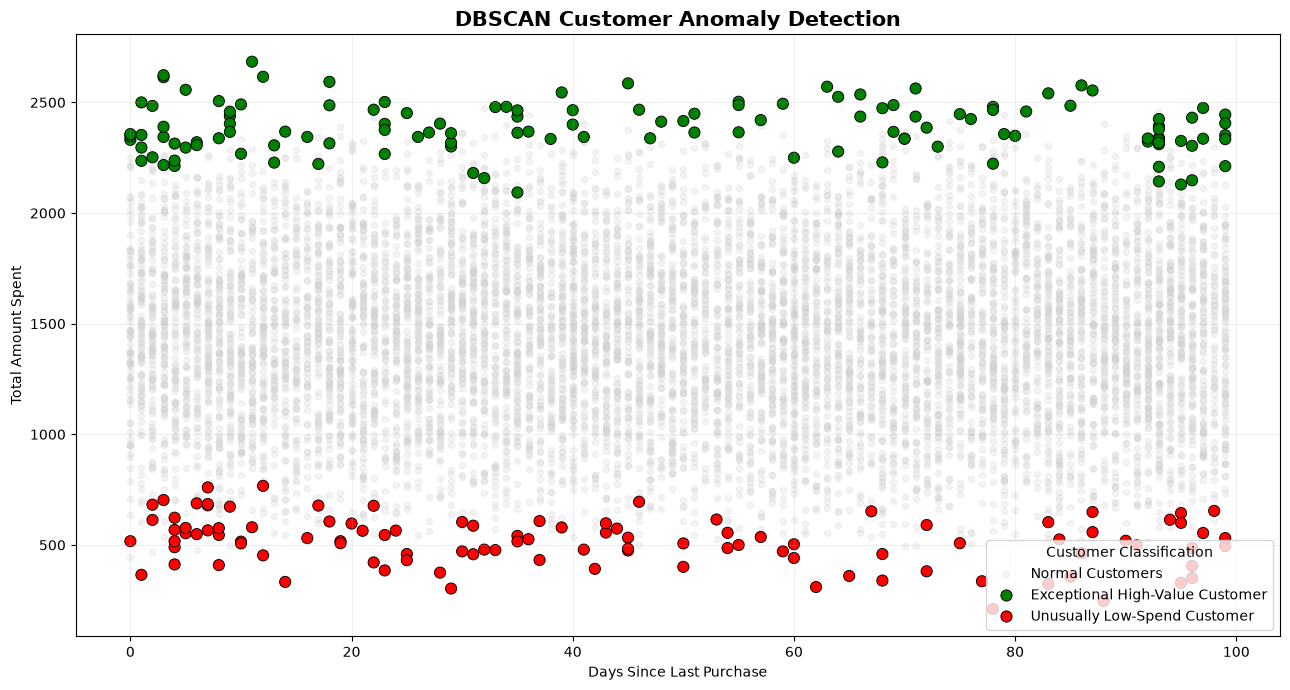

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

normal_customers = dbscan_customer_results[
    dbscan_customer_results["DBSCAN_Label"] != -1
]

anomalous_customers = dbscan_customer_results[
    dbscan_customer_results["DBSCAN_Label"] == -1
]

plt.figure(figsize=(13, 7))

plt.scatter(
    normal_customers["Last_Purchase_Recency"],
    normal_customers["Total_Amount_Spent"],
    color="lightgray",
    alpha=0.25,
    s=20,
    label="Normal Customers"
)

sns.scatterplot(
    data=anomalous_customers,
    x="Last_Purchase_Recency",
    y="Total_Amount_Spent",
    hue="Anomaly_Type",
    palette={
        "Exceptional High-Value Customer": "green",
        "Unusually Low-Spend Customer": "red"
    },
    s=65,
    edgecolor="black"
)

plt.title(
    "DBSCAN Customer Anomaly Detection",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Amount Spent")
plt.legend(title="Customer Classification")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [99]:
final_anomaly_list = (
    dbscan_customer_results[
        dbscan_customer_results["DBSCAN_Label"] == -1
    ]
    .sort_values(
        "Dominant_Deviation_Score",
        ascending=False
    )
)

display(
    final_anomaly_list[
        [
            "Customer_ID",
            "Anomaly_Type",
            "Last_Purchase_Recency",
            "Total_Amount_Spent",
            "Web_Purchases",
            "Catalog_Purchases",
            "Store_Purchases",
            "Dominant_Deviation_Score",
            "Recommended_Action"
        ]
    ].head(10)
)

,Customer_ID,Anomaly_Type,Last_Purchase_Recency,Total_Amount_Spent,Web_Purchases,Catalog_Purchases,Store_Purchases,Dominant_Deviation_Score,Recommended_Action
4368,4369,Exceptional High-Value Customer,11,2684,3,3,3,2.142919,Validate unusual activity and provide VIP rete...
6253,6254,Unusually Low-Spend Customer,78,210,1,1,0,2.142919,"Increase basket value through bundles, cross-s..."
8448,8449,Unusually Low-Spend Customer,88,247,5,0,7,2.078822,"Increase basket value through bundles, cross-s..."
3476,3477,Exceptional High-Value Customer,3,2623,3,9,6,2.037246,Validate unusual activity and provide VIP rete...
8390,8391,Exceptional High-Value Customer,12,2616,6,3,2,2.025119,Validate unusual activity and provide VIP rete...
1088,1089,Exceptional High-Value Customer,3,2614,7,4,5,2.021654,Validate unusual activity and provide VIP rete...
8295,8296,Exceptional High-Value Customer,18,2593,2,0,9,1.985275,Validate unusual activity and provide VIP rete...
3386,3387,Unusually Low-Spend Customer,29,303,0,8,1,1.981810,"Increase basket value through bundles, cross-s..."
9836,9837,Exceptional High-Value Customer,45,2586,9,4,1,1.973149,Validate unusual activity and provide VIP rete...
363,364,Unusually Low-Spend Customer,62,310,5,4,2,1.969684,"Increase basket value through bundles, cross-s..."


In [100]:
final_anomaly_list.to_csv(
    "dbscan_customer_anomalies.csv",
    index=False
)

### DBSCAN Anomaly Detection — Final Results

DBSCAN was applied using customer recency, total spending, web purchases,
catalog purchases and store purchases. RobustScaler was used because it is
less affected by extreme customer values.

After evaluating multiple parameter combinations, `eps = 0.514` and
`min_samples = 15` were selected. This configuration showed consistent anomaly
overlap with neighbouring parameter settings, with Jaccard similarity values
between 0.700 and 0.729.

The final model identified:

- 9,766 normal customers (97.66%)
- 234 anomalous customers (2.34%)

The silhouette score was not calculated because DBSCAN produced one dense
normal cluster. This is valid for anomaly detection, where the objective is to
separate normal observations from noise rather than create multiple customer
segments.

The 234 anomalous customers were divided into two actionable groups:

1. **Exceptional High-Value Customers**
   - 128 customers
   - Median spending: 2,367.5
   - Spending range: 2,093 to 2,684
   - Recommended action: validate unusual activity and provide personalized
     VIP retention benefits.

2. **Unusually Low-Spend Customers**
   - 106 customers
   - Median spending: 518
   - Spending range: 210 to 767
   - These customers are relatively recent purchasers rather than clearly
     inactive customers.
   - Recommended action: increase their basket value through bundles,
     cross-selling and targeted product offers.

DBSCAN anomalies should not automatically be treated as fraud or data errors.
They represent customers whose combined purchasing behaviour occurs in
low-density regions and therefore requires business investigation.